---
numbering: false
---

# 3.1. Vectors and Linear Combinations

**Linear** algebra can be thought of as the study of vectors, matrices, and **linear** transformations, all of which are ideas we'll need to use in our journey to understand machine learning. We'll start with vectors, which are the building blocks of linear algebra.

## Definition

There are many ways to define vectors, but I'll give you the most basic and practically relevant definition of a vector for now. I'll introduce more abstract definitions later if we need them.

:::{note} Definition: Vector
A **vector** is an ordered list of numbers.

In this class, we'll typically use lowercase letters to denote vectors, drawn with arrows above the letters. For example:

$$\vec v = \begin{bmatrix} 4 \\ -3 \\ 15 \end{bmatrix}$$

In other classes or textbooks, you might see vectors written as boldface letters, like $\mathbf{v}$, or simply $v$.
:::

By _ordered list_, I mean that the order of the numbers in the vector matters. 
- For example, the vector $\vec v = \begin{bmatrix} 4 \\ -3 \\ 15 \end{bmatrix}$ is not the same as the vector $\vec w = \begin{bmatrix} 15 \\ -3 \\ 4 \end{bmatrix}$, even though they have the same components.
- $\vec v$ is also different from the vector $\vec u = \begin{bmatrix} 4 \\ -3 \\ 15 \\ 1 \end{bmatrix}$, even though their first three components are the same.

In general, we're mostly concerned with vectors in $\mathbb{R}^n$, which is the **set** of all vectors with $n$ **components** or **elements**, each of which is a real number. It's possible to consider vectors with complex components (the set of all vectors with complex components is denoted $\mathbb{C}^n$), but we'll stick to real vectors for now.

The vector $\vec v$ defined in the box above is in $\mathbb{R}^3$, which we can express as $\vec v \in \mathbb{R}^3$. This is pronounced as "v is an element of R three", or "v is in R three".

A general vector in $\mathbb{R}^n$ can be expressed in terms of its $n$ components:

$$\vec v = \begin{bmatrix} v_1 \\ v_2 \\ \vdots \\ v_n \end{bmatrix}$$

Subscripts can be used for different, sometimes conflicting purposes:

- In the definition of $\vec v$ above, the components of the vector are denoted $v_1, v_2, \ldots, v_n$. Each of these individual components is a single real number – known as a **scalar** – not a vector. 
- But in the near future, we may want to consider multiple vectors at once, and may use subscripts to refer to them as well. For instance, I might have $d$ different vectors, $\vec v_1, \vec v_2, \ldots, \vec v_d$, each corresponding to some feature I care about.

The meaning of the subscript depends on the context, so just be careful!

While we'll use the definition of a vector as a list of numbers for now, I hope you'll soon appreciate that vectors are more than just a list of numbers – they encode remarkable amounts of information and beauty.

---

## Norm (i.e. Length or Magnitude)

In the context of physics, vectors are often described as creatures with "a magnitude and a direction". While this is not a physics class – this is EECS 245, after all! – this interpretation has some value for us too.

To illustrate what we mean, let's consider some concrete vectors in $\mathbb{R}^2$, since it is easy to visualize vectors in 2 dimensions on a computer screen. Suppose: $${\color{orange}\vec u = \begin{bmatrix} 3 \\ 1 \end{bmatrix}}, \quad {\color{3d81f6}\vec v = \begin{bmatrix} 4 \\ -6 \end{bmatrix}}$$

Then, we can visualize $\color{orange}{\vec u}$ and $\color{#3d81f6}{\vec v}$ as arrows pointing from the origin $(0,0)$ to the points $(3, 1)$ and $(4, -6)$ in the two dimensional Cartesian plane, respectively.

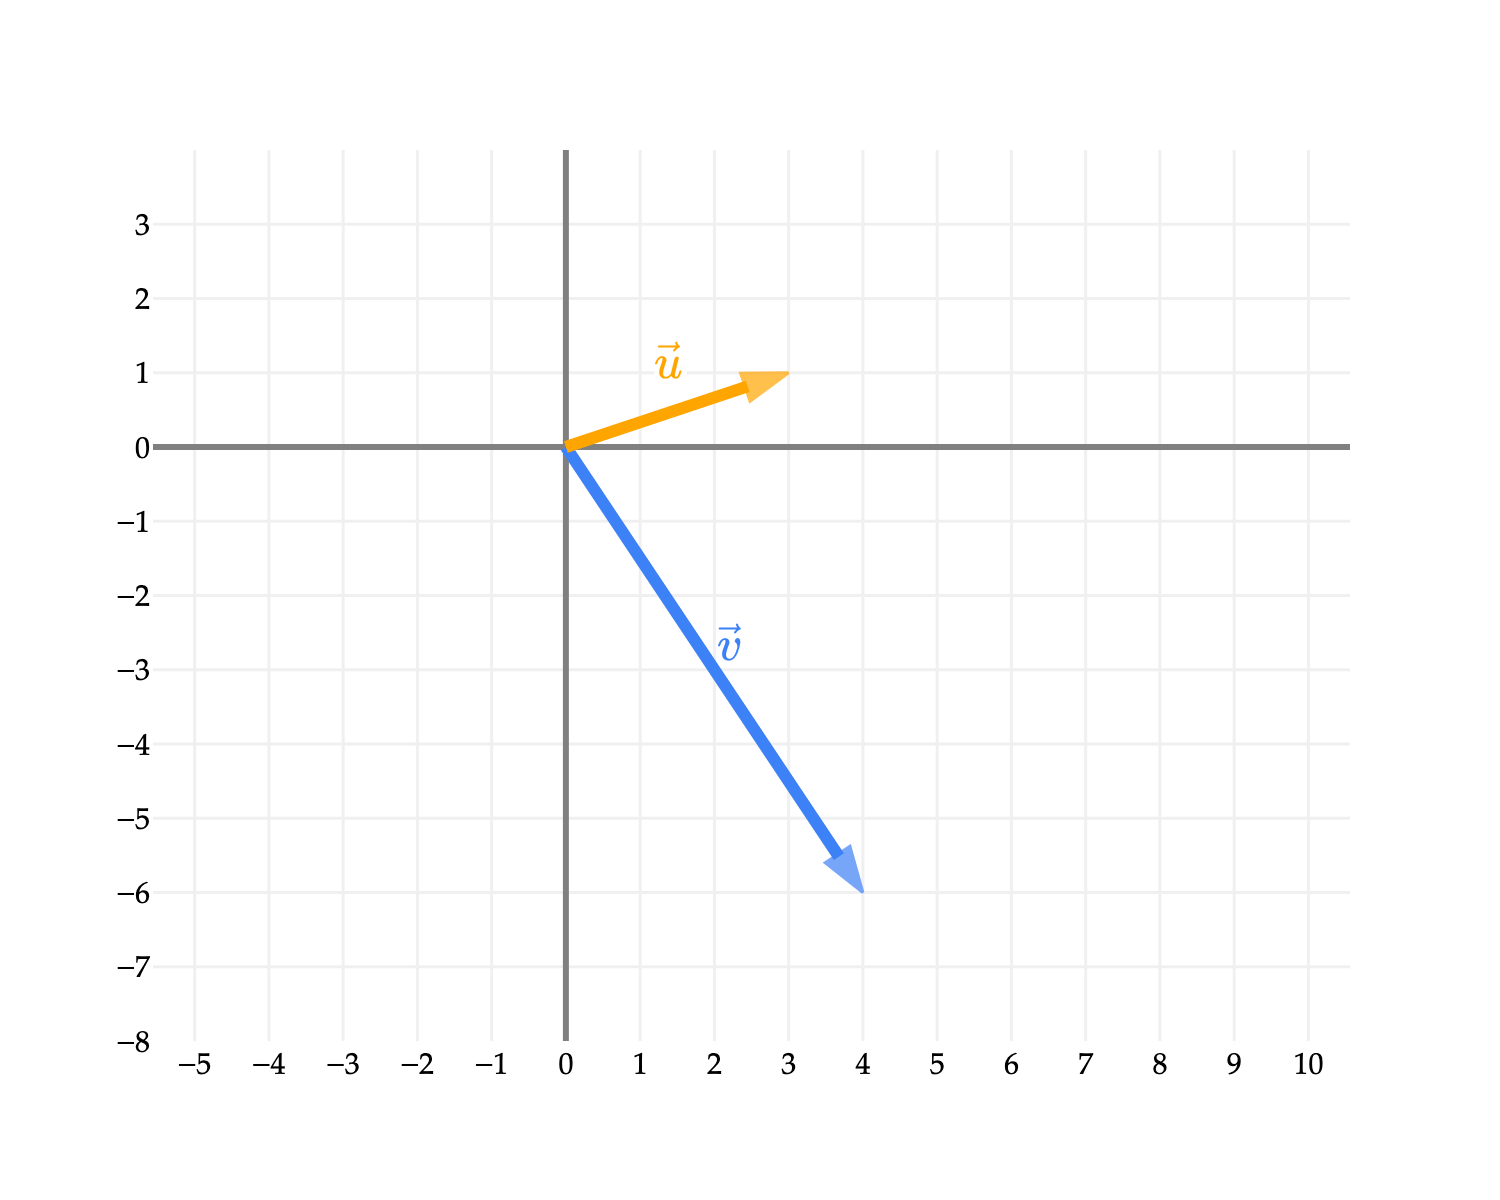

In [11]:
# This chunk must be in the first plotting cell of each notebook in order to guarantee that the mathjax script is loaded.
import plotly
from IPython.display import display, HTML

# Set default renderer to high-DPI static image
plotly.io.renderers.default = "png"

display(HTML(
    '<script type="text/javascript" async src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.1/MathJax.js?config=TeX-MML-AM_SVG"></script>'
))

# ---

from utils import plot_vectors
import numpy as np

fig = plot_vectors([((4, -6), '#3d81f6', r'$\vec v$'), ((3, 1), 'orange', r'$\vec u$')], vdeltax=0.3, vdeltay=0.8)
fig.update_layout(width=500, height=400, yaxis_scaleanchor="x")
fig.update_xaxes(range=[-1, 6], tickvals=np.arange(-5, 15))
fig.update_yaxes(range=[-8, 4], tickvals=np.arange(-8, 4))
fig.show(scale=3)

The vector $\vec v = \begin{bmatrix} 4 \\ -6 \end{bmatrix}$ moves 4 units to the right and 6 units down, which we know by reading the components of the vector. In [Chapter 7.3](03-dot-product.ipynb), we'll see how to describe the direction of $\vec v$ in terms of the angle it makes with the $x$-axis (and you may remember how to calculate that angle using trigonometry).

It's worth noting that $\vec v$ isn't "fixed" to start at the origin – vectors don't have fixed positions. All three vectors in the figure below are the same vector, $\vec v$.

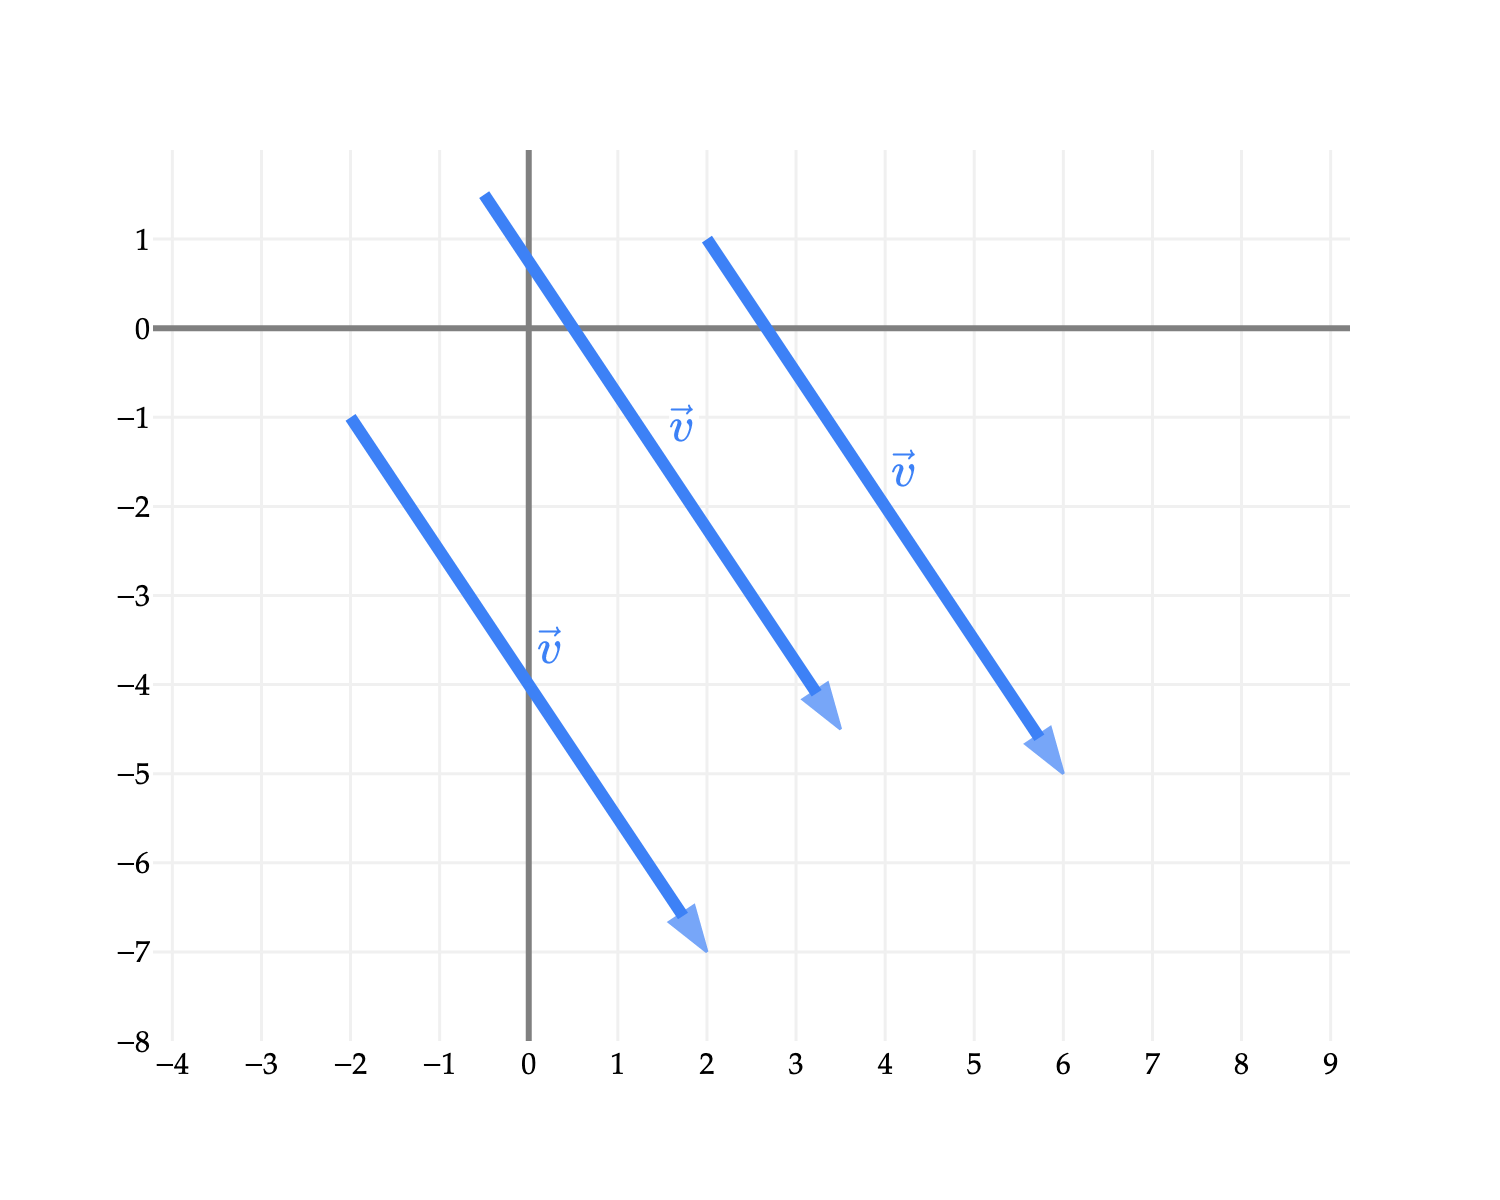

In [13]:
from utils import plot_vectors_non_origin
import numpy as np

vectors_non_origin_2d = [
    (((2, 1), (2 + 4, 1 - 6)), "#3d81f6", r"$\vec v$"),     
    (((-0.5, 1.5), (-0.5 + 4, 1.5 - 6)), "#3d81f6", r"$\vec v$"),
    (((-2, -1), (-2 + 4, -1 - 6)), "#3d81f6", r"$\vec v$")
]
fig = plot_vectors_non_origin(vectors_non_origin_2d, vdeltay=0.9)
fig.update_layout(width=500, height=400, yaxis_scaleanchor="x")
fig.update_xaxes(range=[-1, 6], tickvals=np.arange(-5, 15))
fig.update_yaxes(range=[-8, 2], tickvals=np.arange(-8, 2))
fig.show(config={'displayModeBar': False}, scale=3)


To compute the length of $\vec v$ – i.e. the distance between $(0, 0)$ and $(4, -6)$ – we should remember the Pythagorean theorem, which states that if we have a right triangle with legs of length $a$ and $b$, then the length of the hypotenuse is $\sqrt{a^2 + b^2}$. Here, that's $\sqrt{4^2 + (-6)^2} = \sqrt{16 + 36} = \sqrt{52} = 2\sqrt{13}$.

<script type="text/javascript" src="https://cdn.mathjax.org/mathjax/latest/MathJax.js?config=TeX-AMS-MML_HTMLorMML"></script>

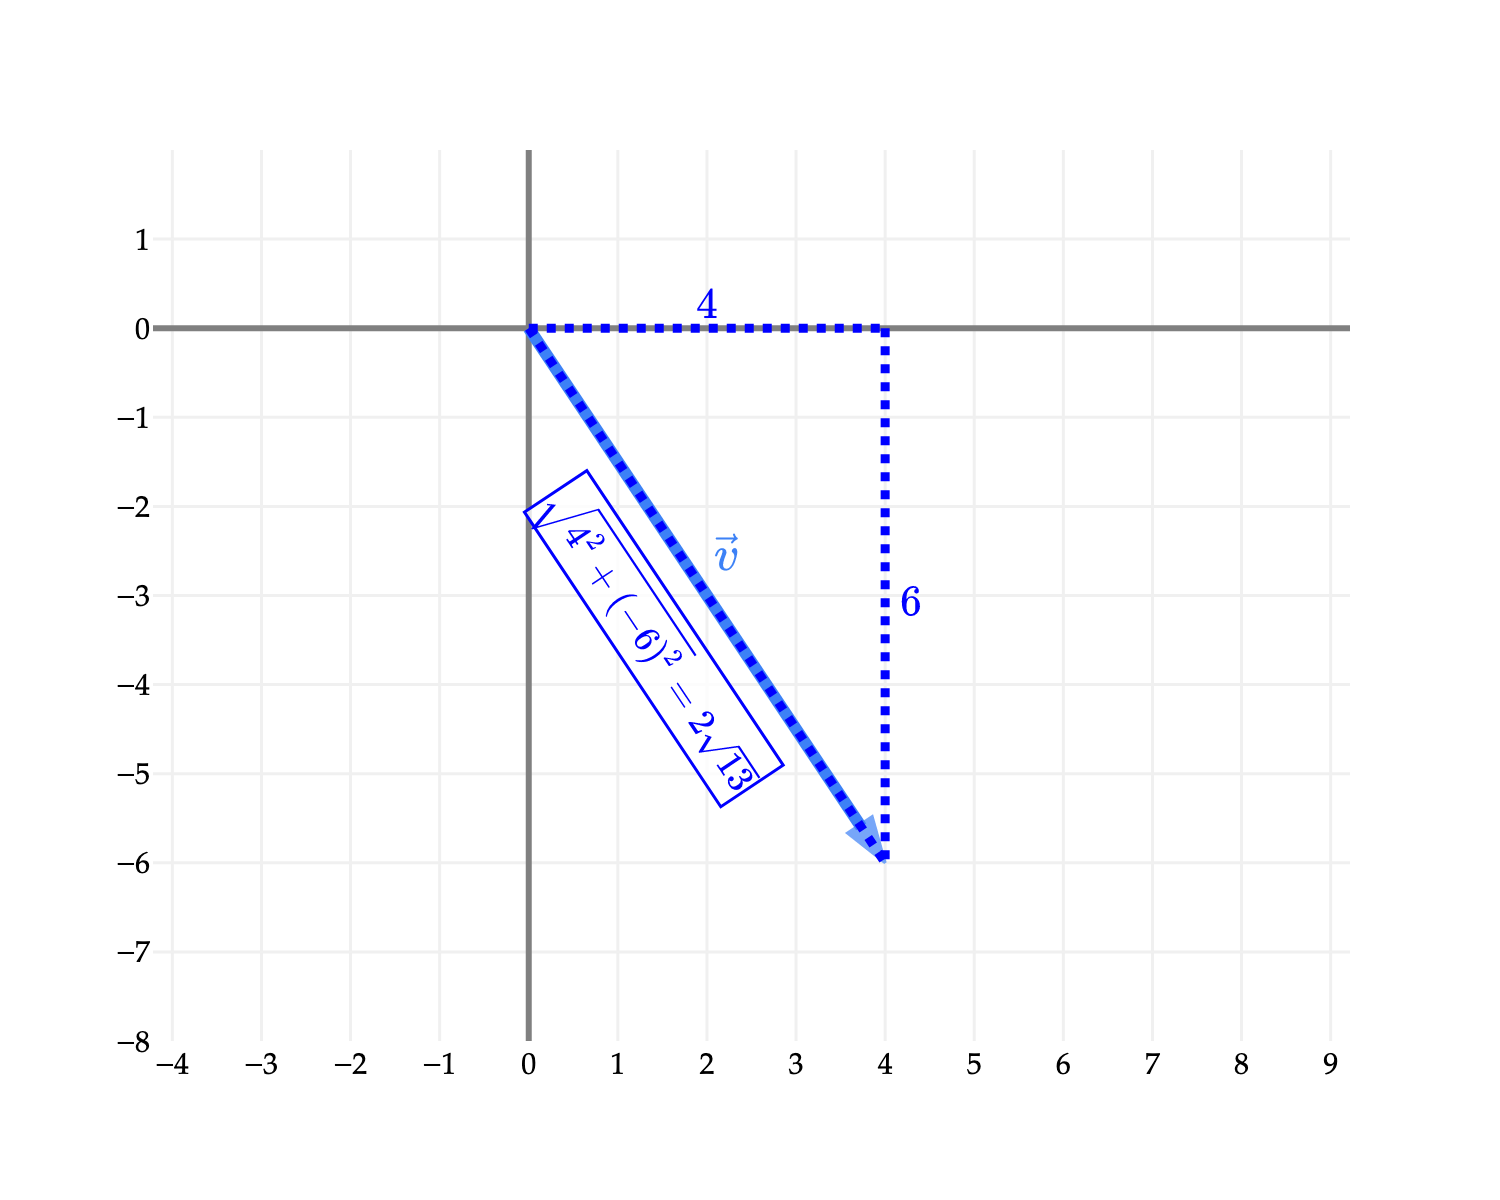

In [15]:
from utils import plot_vectors
import numpy as np

fig = plot_vectors([((4, -6), '#3d81f6', r'$\vec v$')], vdeltax=0.3, vdeltay=1)

# Add horizontal dotted line from (0,0) to (4,0)
fig.add_shape(
    type="line",
    x0=0, y0=0, x1=4, y1=0,
    line=dict(color="blue", width=3, dash="dot")
)

# Add vertical dotted line from (4,0) to (4,-6)
fig.add_shape(
    type="line",
    x0=4, y0=0, x1=4, y1=-6,
    line=dict(color="blue", width=3, dash="dot")
)

# Add label "4" above the horizontal line
fig.add_annotation(
    x=2, y=0.3,
    text="$4$",
    showarrow=False,
    font=dict(size=14, color="blue")
)

# Add label "6" to the right of the vertical line
fig.add_annotation(
    x=4.3, y=-3,
    text="$6$",
    showarrow=False,
    font=dict(size=14, color="blue")
)

# Add diagonal dotted line from (0,0) to (4,-6) - the hypotenuse
fig.add_shape(
    type="line",
    x0=0, y0=0, x1=4, y1=-6,
    line=dict(color="blue", width=3, dash="dot")
)

# Add calculation annotation for the hypotenuse
fig.add_annotation(
    x=1.4, y=-3.5,
    text=r"$$\sqrt{4^2 + (-6)^2} = 2\sqrt{13}$$",
    showarrow=False,
    font=dict(size=12, color="blue"),
    bgcolor="rgba(255,255,255,0.8)",
    bordercolor="blue",
    borderwidth=1,
    textangle=np.arctan(6/4) * 180 / np.pi
)

fig.update_layout(width=500, height=400, yaxis_scaleanchor="x")
fig.update_xaxes(range=[-1, 6], tickvals=np.arange(-5, 15))
fig.update_yaxes(range=[-8, 2], tickvals=np.arange(-8, 2))
fig.show(config={'displayModeBar': False}, scale=3)

:::{note} Definition: Vector Norm
The **norm** of a vector $\vec v \in \mathbb{R}^n$ is defined as follows:

$$\left\| \vec v \right\| = \sqrt{v_1^2 + v_2^2 + \cdots + v_n^2} = \sqrt{\sum_{i=1}^n v_i^2}$$

The norm of a vector is also called its **length** or **magnitude**. This particular formula for the norm is also called the **$L_2$ norm** or **Euclidean norm** (after the Greek mathematician Euclid), and is the most common and "default" norm used in linear algebra. 

:::

Note that the norm involves a sum of _squares_, much like mean _squared_ error 🤯. This connection will be made more explicit in Chapter 7, when we return to studying linear regression.

Shortly, we'll see other norms, which describe different ways of measuring the "length" of a vector.


:::{tip} Activity 1
:class: dropdown

As we'll see later in this section, a **unit vector** is a vector with norm 1. It's common to use unit vectors to describe directions. For instance, there are infinitely many vectors in $\mathbb{R}^2$ that point in the same direction as $\vec v = \begin{bmatrix} 4 \\ -6 \end{bmatrix}$ from above, like $\begin{bmatrix} 2 \\ -3 \end{bmatrix}$ and $\begin{bmatrix} 40 \\ -60 \end{bmatrix}$. (If you don't believe me, draw it out!)

Find a unit vector that points in the same direction as the vector $\vec x = \begin{bmatrix} 12 \\ 5 \end{bmatrix}$, and verify that it has norm 1. Technically, to answer this, you'll need to use the fact that vectors can be multiplied by a scalar, which we haven't yet discussed, but see how far your intuition takes you!

:::

What may not be immediately obvious is _why_ the Pythagorean theorem seems to extend to higher dimensions. The two dimensional case seems reasonable, but why is the length of the vector $\color{#d81b60}\vec w = \begin{bmatrix} 6 \\ -2 \\ 3 \end{bmatrix}$ in $\mathbb{R}^3$ equal to $\sqrt{6^2 + (-2)^2 + 3^2}$?

In [1]:
from pathlib import Path
import sys
_notes_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'myst.yml').exists())
if str(_notes_root) not in sys.path:
    sys.path.insert(0, str(_notes_root))
from plane_style import style_vector_figure, vector_label

from utils import plot_vectors
import numpy as np
import plotly.graph_objects as go

fig = plot_vectors([((6, -2, 3), '#d81b60', '<b>w</b>')], vdeltax=-0.6)

# Add light blue triangle connecting (0, 0, 0), (0, -2, 0), and (6, -2, 0)
fig.add_trace(go.Mesh3d(
    x=[0, 0, 6],
    y=[0, -2, -2],
    z=[0, 0, 0],
    i=[0],
    j=[1],
    k=[2],
    color='#3d81f6',
    opacity=0.24,
    showscale=False,
    name='Triangle 1'
))

# Add red triangle connecting (0, 0, 0), (6, -2, 0) and (6, -2, 3)
fig.add_trace(go.Mesh3d(
    x=[0, 6, 6],
    y=[0, -2, -2],
    z=[0, 0, 3],
    i=[0],
    j=[1],
    k=[2],
    color='#d81b60',
    opacity=0.24,
    showscale=False,
    name='Triangle 2'
))

# Add dotted blue lines for the edges
edges = [
    # Edge "2": (0,0,0) to (0,-2,0)
    ([0, 0], [0, -2], [0, 0]),
    # Edge "6": (0,-2,0) to (6,-2,0)
    ([0, 6], [-2, -2], [0, 0]),
    # Edge "h": (0,0,0) to (6,-2,0)
    ([0, 6], [0, -2], [0, 0]),
    # Edge "3": (6,-2,0) to (6,-2,3)
    ([6, 6], [-2, -2], [0, 3])
]

for x_coords, y_coords, z_coords in edges:
    fig.add_trace(go.Scatter3d(
        x=x_coords, y=y_coords, z=z_coords,
        mode='lines',
        line=dict(color='#3d81f6', width=3, dash='dash'),
        showlegend=False
    ))

# Add vertex labels with better positioning
vertices = {
    '(0,0,0)': (-0.3, 0.3, 0.2),
    '(0,-2,0)': (-0.3, -2.3, 0.2),
    '(6,-2,0)': (6.3, -2.3, 0.2),
    '(6,-2,3)': (6.3, -2.3, 3.3)
}

for label, (x, y, z) in vertices.items():
    fig.add_trace(go.Scatter3d(
        x=[x], y=[y], z=[z],
        mode='text',
        text=[label],
        textfont=dict(size=12, color='black', family='Palatino'),
        textposition='middle center',
        showlegend=False
    ))

# Add edge labels at adjusted positions to avoid triangular areas
edge_labels = {
    '2': (-0.5, -1, 0),     # shifted left from midpoint of (0,0,0) to (0,-2,0)
    '6': (2.2, -2.2, 0),     # shifted up and back from midpoint of (0,0,0) to (6,-2,0)
    '3': (6.5, -2.1, 1.5),       # shifted right from midpoint of (6,-2,0) to (6,-2,3)
    '<i>h</i>': (4, -1, -0)     # shifted up and back from midpoint of (0,0,0) to (6,-2,0)
}

for label, (x, y, z) in edge_labels.items():
    fig.add_trace(go.Scatter3d(
        x=[x], y=[y], z=[z],
        mode='text',
        text=[label],
        textfont=dict(size=14, color='#3d81f6', family='Palatino'),
        textposition='middle center',
        showlegend=False
    ))

fig.update_layout(
    scene=dict(
        camera=dict(
            eye=dict(x=1.25, y=1.25, z=0.9)
        )
    )
)
style_vector_figure(fig, height=520)
# Keep the vector name clear of the endpoint's coordinate label.
for trace in fig.data:
    if trace.type == 'scatter3d' and list(trace.text or []) == [vector_label('w')]:
        trace.update(x=[3], y=[-1], z=[2.6])
fig.update_layout(scene_yaxis_range=[-4, 2], scene_aspectmode='data')
fig.show(renderer='plotly_mimetype')

There are two right angle triangles in the picture above:
- One triangle has legs of length 6 and 2, with a hypotenuse of $h$; this triangle is shaded $\color{lightblue} \text{light blue}$ above.
- Another triangle has legs of length 3 and $h$, with a hypotenuse of $\left\| \vec w \right\|$; this triangle is shaded $\color{#d81b60} \text{dark pink}$ above.

To find $\left\| \vec w \right\|$, we can use the Pythagorean theorem twice:

$$h^2 = 6^2 + (-2)^2 = 36 + 4 = 40 \implies h = \sqrt{40}$$

Then, we can use the Pythagorean theorem again to find $\left\| \vec w \right\|$:

$$\left\| \vec w \right\| = \sqrt{h^2 + 3^2} = \sqrt{40 + 9} = 7 = \sqrt{6^2 + (-2)^2 + 3^2}$$

So, to find $\left\| \vec w \right\|$, we used the Pythagorean theorem twice, and ended up computing the square root of the sum of the squares of the components of the vector, which is what the definition above states. 

This argument naturally extends to higher dimensions. We will do this often: build intuition in the dimensions we can visualize (two dimensions, and with the help of interactive graphics, three dimensions), and then rely on the power of abstraction to extend our understanding to higher dimensions, even when we can't visualize. **Thinking in higher dimensions** is one of the key objectives of this course.

```{warning} Length $\neq$ Number of Components

**Don't** confuse the length of a vector with the number of components in a vector!

If $\vec v \in \mathbb{R}^n$, then the length of $\vec v$ is $\lVert \vec v \rVert = \sqrt{v_1^2 + v_2^2 + \cdots + v_n^2}$, while the number of components in $\vec v$ is $n$.
```

Vector norms satisfy several interesting properties, which we will introduce shortly once we have more context.

---

## Addition and Scalar Multiplication

Vectors support two core operations: addition and scalar multiplication. These two operations are core to the study of linear algebra – so much so, that sometimes vectors are defined abstractly as "things that can be added and multiplied by scalars".

### Addition

:::{note} Definition: Vector Addition
Suppose ${\color{orange} \vec u}, {\color{#3d81f6} \vec v} \in \mathbb{R}^n$, i.e. both are vectors with $n$ components.

Then, the **sum** of ${\color{orange} \vec u}$ and ${\color{#3d81f6} \vec v}$ is defined as follows:

$${\color{orange} \vec u} + {\color{#3d81f6} \vec v} = {\color{orange} \begin{bmatrix} u_1 \\ u_2 \\ \vdots \\ u_n \end{bmatrix}} + {\color{#3d81f6} \begin{bmatrix} v_1 \\ v_2 \\ \vdots \\ v_n \end{bmatrix}} = \begin{bmatrix} {\color{orange} u_1} + {\color{#3d81f6} v_1} \\ {\color{orange} u_2} + {\color{#3d81f6} v_2} \\ \vdots \\ {\color{orange} u_n} + {\color{#3d81f6} v_n} \end{bmatrix}$$


:::

Using our examples from earlier, $\color{orange}\vec u = \begin{bmatrix} 3 \\ 1 \end{bmatrix}$ and $\color{#3d81f6}\vec v = \begin{bmatrix} 4 \\ -6 \end{bmatrix}$, we have that ${\color{orange}\vec u} + {\color{#3d81f6}\vec v} = \begin{bmatrix} 7 \\ -5 \end{bmatrix}$. 

Geometrically, we can arrive at the vector $\begin{bmatrix} 7 \\ -5 \end{bmatrix}$ by drawing ${\color{orange}\vec u}$ at the origin, then placing ${\color{#3d81f6}\vec v}$ at the tip of ${\color{orange}\vec u}$.

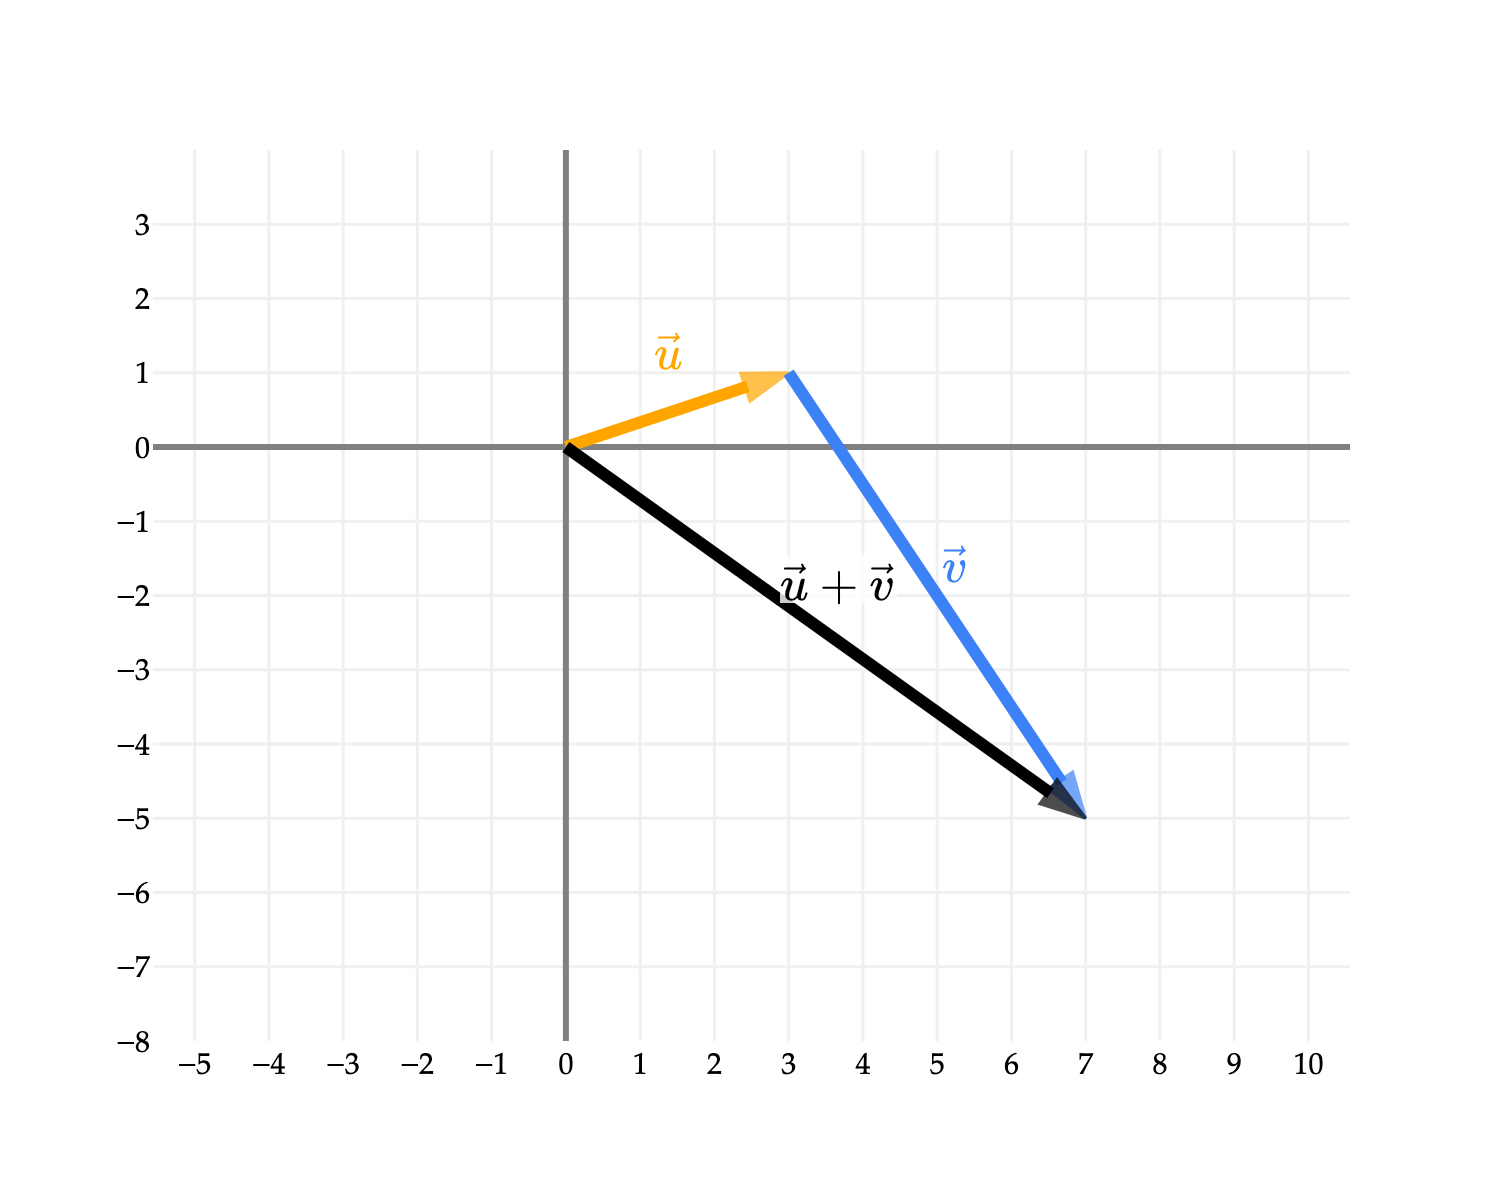

In [18]:
from utils import plot_vectors_non_origin
import numpy as np

fig = plot_vectors_non_origin([(((0, 0), (3, 1)), 'orange', r'$\vec u$'),
                               (((3, 1), (3 + 4, 1 - 6)), '#3d81f6', r'$\vec v$'),
                               (((0, 0), (7, -5)), 'black', r'$\vec u + \vec v$')
                               ]
                               , vdeltax=0.3, vdeltay=0.9)
fig.update_layout(width=500, height=400, yaxis_scaleanchor="x")
fig.update_xaxes(range=[-1, 6], tickvals=np.arange(-5, 15))
fig.update_yaxes(range=[-8, 4], tickvals=np.arange(-8, 4))
fig.show(scale=3)

Vector addition is commutative, i.e. ${\color{orange}\vec u} + {\color{#3d81f6}\vec v} = {\color{#3d81f6}\vec v} + {\color{orange}\vec u}$, for any two vectors ${\color{orange}\vec u}, {\color{#3d81f6}\vec v} \in \mathbb{R}^n$. Algebraically, this should not be a surprise, since ${\color{orange}u_i} + {\color{#3d81f6}v_i} = {\color{#3d81f6}v_i} + {\color{orange}u_i}$ for all $i$.

Visually, this means that we can instead start with ${\color{#3d81f6}\vec v}$ at the origin and then draw ${\color{orange}\vec u}$ starting from the tip of ${\color{#3d81f6}\vec v}$, and we should land in the same place.

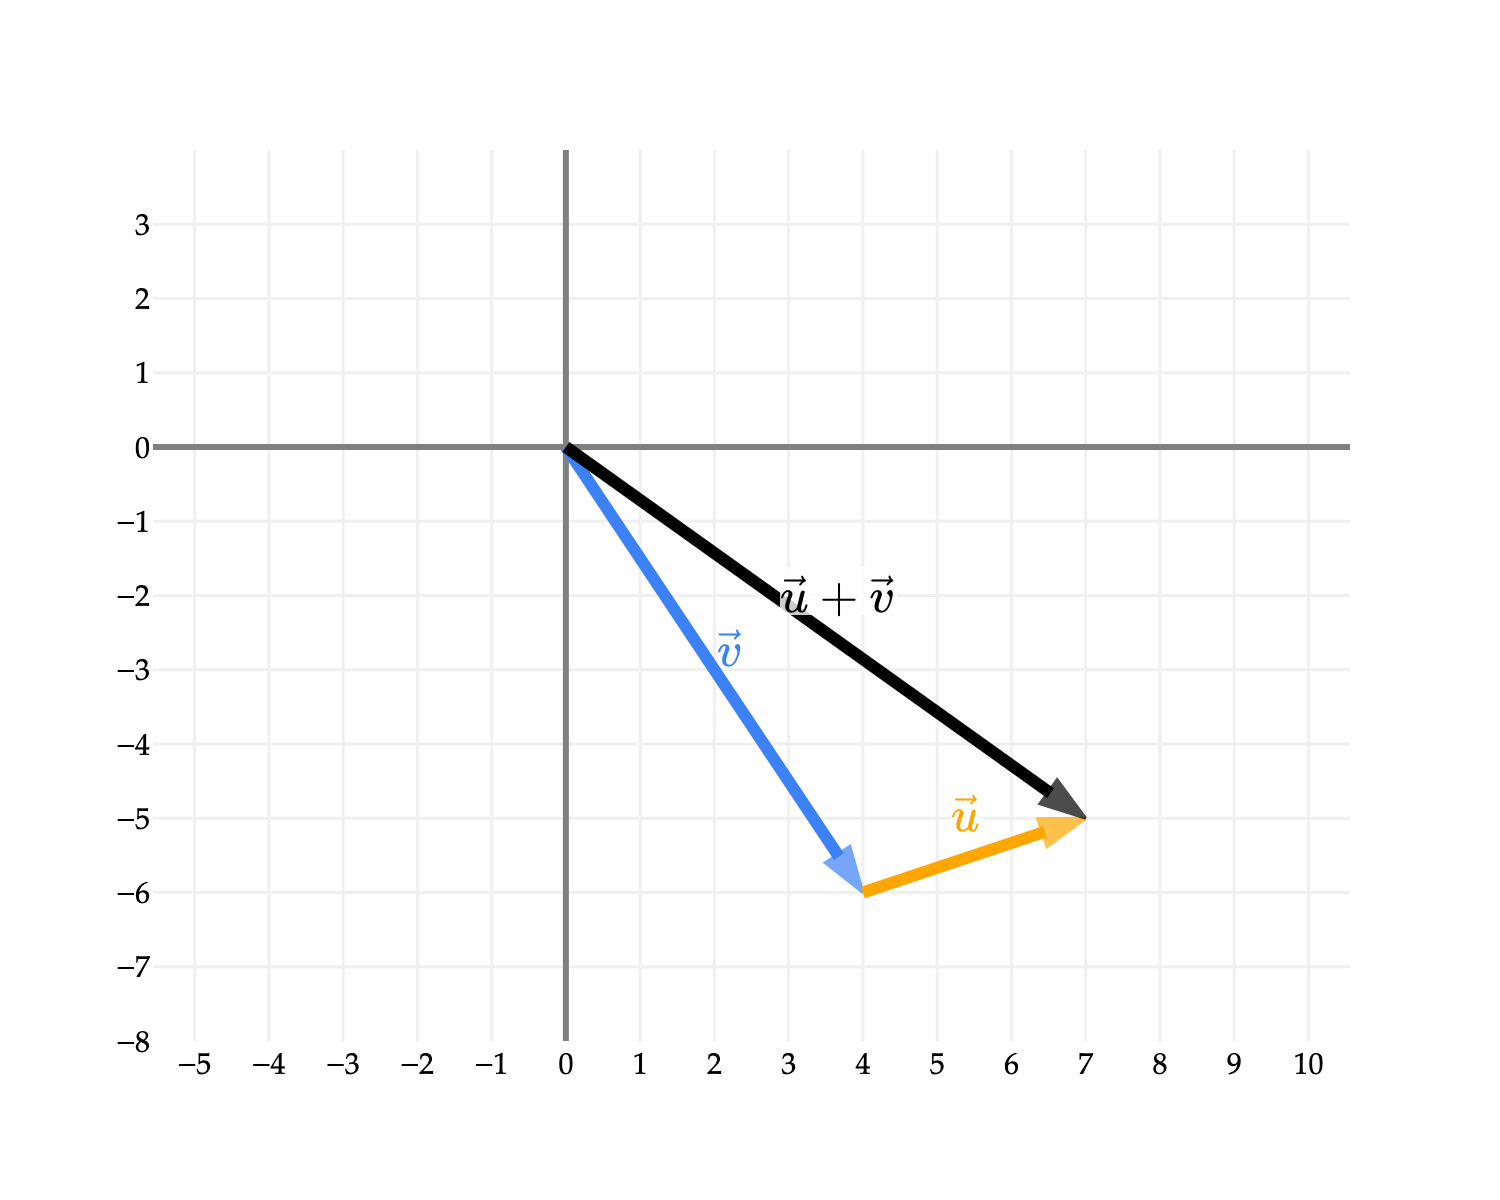

In [20]:
from utils import plot_vectors
import numpy as np

fig = plot_vectors_non_origin([(((0, 0), (4, -6)), '#3d81f6', r'$\vec v$'),
                               (((4, -6), (4 + 3, -6 + 1)), 'orange', r'$\vec u$'),
                               (((0, 0), (7, -5)), 'black', r'$\vec u + \vec v$')
                               ]
                               , vdeltax=0.3, vdeltay=0.7)
fig.update_layout(width=500, height=400, yaxis_scaleanchor="x")
fig.update_xaxes(range=[-1, 6], tickvals=np.arange(-5, 15))
fig.update_yaxes(range=[-8, 4], tickvals=np.arange(-8, 4))
fig.show(scale=3)

We cannot, however, add $\vec w = \begin{bmatrix} 6 \\ -2 \\ 3 \end{bmatrix}$ to $\vec u$, since $\vec u$ and $\vec w$ have different numbers of components.

In Python, we define vectors using `numpy` arrays, and addition occurs element-wise by default.

<iframe
  src="https://jupyterlite.github.io/demo/repl/index.html?kernel=python&code=import%20numpy%20as%20np%0Au%20%3D%20np.array%28%5B3%2C%201%5D%29%0Av%20%3D%20np.array%28%5B4%2C%20-6%5D%29%0A&code=u%20%2B%20v"
  width="100%"
  height="500px"
></iframe>

:::{tip} Activity 2
:class: dropdown

In the cell above, try and define $\vec w = \begin{bmatrix} 6 \\ -2 \\ 3 \end{bmatrix}$ as an array and add it to `u`. What error do you see?

:::


### Scalar Multiplication

:::{note} Definition: Scalar Multiplication
Suppose ${\color{#3d81f6} \vec v} \in \mathbb{R}^n$. The **scalar multiple** of $\color{#3d81f6}\vec v$ by a scalar $c \in \mathbb{R}$ is defined as follows:

$$c {\color{#3d81f6} \vec v} = c {\color{#3d81f6} \begin{bmatrix} v_1 \\ v_2 \\ \vdots \\ v_n \end{bmatrix}} = \begin{bmatrix} c {\color{#3d81f6} v_1} \\ c {\color{#3d81f6} v_2} \\ \vdots \\ c {\color{#3d81f6} v_n} \end{bmatrix}$$
:::

Using our examples from earlier, $\color{#3d81f6}\vec v = \begin{bmatrix} 4 \\ -6 \end{bmatrix}$ as an example, $3 {\color{#3d81f6}\vec v} = \begin{bmatrix} 12 \\ -18 \end{bmatrix}$. Note that I've deliberately defined this operation as **scalar** multiplication, not just "multiplication" in general, as there's more nuance to the definition of multiplication in linear algebra.

Visually, a scalar multiple is equivalent to stretching or compressing a vector by a factor of the scalar. If the scalar is negative, the direction of the vector is reversed. Below, $-\frac{2}{3} \color{#3d81f6}\vec v$ points opposite to $\color{#3d81f6}\vec v$ and $3 \color{#3d81f6}\vec v$.

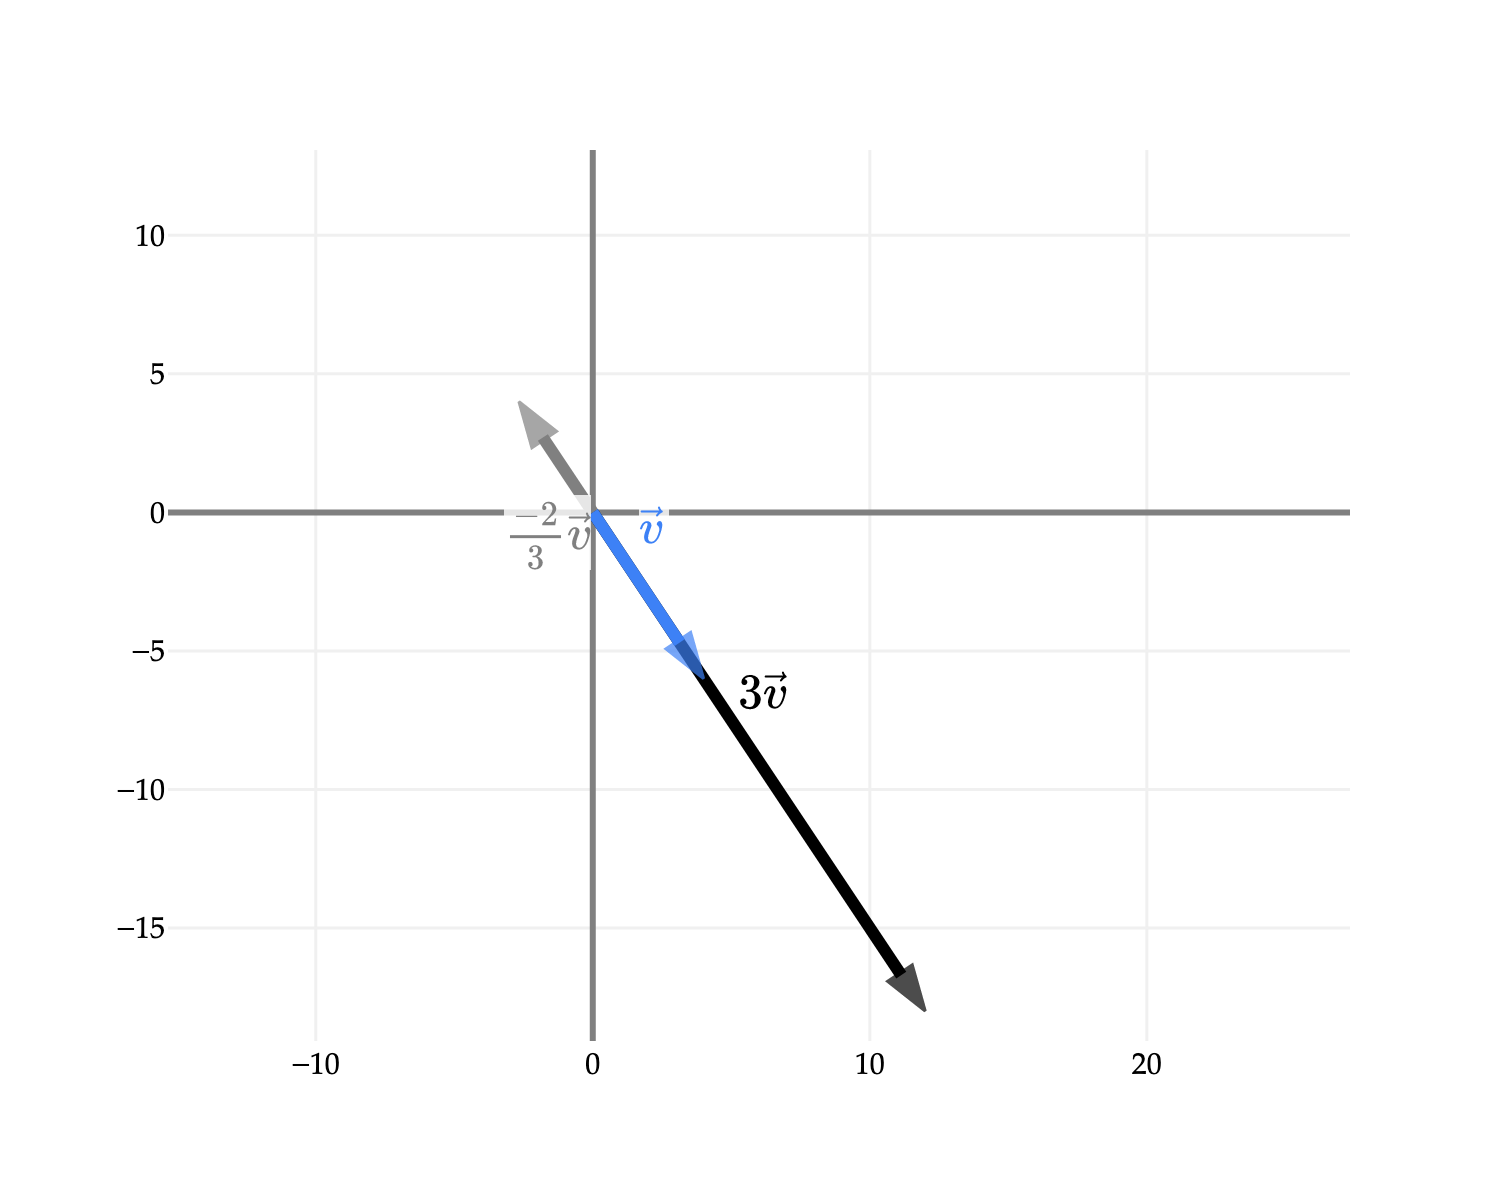

In [21]:
from utils import plot_vectors
import numpy as np

fig = plot_vectors([((4 * 3, -6 * 3), 'black', r'$3 \vec v$'),
                    ((4 * (-2 / 3), -6 * (-2 / 3)), 'gray', r'$\frac{-2}{3} \vec v$'),
                    ((4, -6), '#3d81f6', r'$\vec v$')], vdeltax=0.3, vdeltay=5)
fig.update_layout(width=500, height=400, yaxis_scaleanchor="x", xaxis_range=[-3, 15])
fig.show(scale=3)

An important observation is that $\color{#3d81f6}\vec v$, $3 \color{#3d81f6}\vec v$, and $-\frac{2}{3} \color{#3d81f6}\vec v$ **all lie on the same line**.

:::{tip} Activity 3
:class: dropdown

Addition and scalar multiplication can be used at the same time, as we're about to see in the next subsection.

Find the vector $\vec x$ such that:

$$3\begin{bmatrix} 7 \\ 3 \\ -2 \end{bmatrix} + 4 \vec x = \begin{bmatrix} 9 \\ 4 \\ 2 \end{bmatrix}$$

:::

---

## Linear Combinations

### Motivation and Definition

The two operations we've defined – vector addition and scalar multiplication – are the building blocks of linear algebra, and are often used in conjunction. For example, if we stick with the same vectors $\color{orange} \vec u$ and $\color{#3d81f6} \vec v$ from earlier, what might the vector $3 {\color{orange} \vec u} - \frac{1}{2} {\color{#3d81f6} \vec v}$ look like?

$$3 {\color{orange} \vec u} - \frac{1}{2} {\color{#3d81f6} \vec v} = 3 {\color{orange} \begin{bmatrix} 3 \\ 1 \end{bmatrix}} - \frac{1}{2} {\color{#3d81f6} \begin{bmatrix} 4 \\ -6 \end{bmatrix}} = \begin{bmatrix} 9 \\ 3 \end{bmatrix} - \begin{bmatrix} 2 \\ -3 \end{bmatrix} = \begin{bmatrix} 7 \\ 6 \end{bmatrix}$$

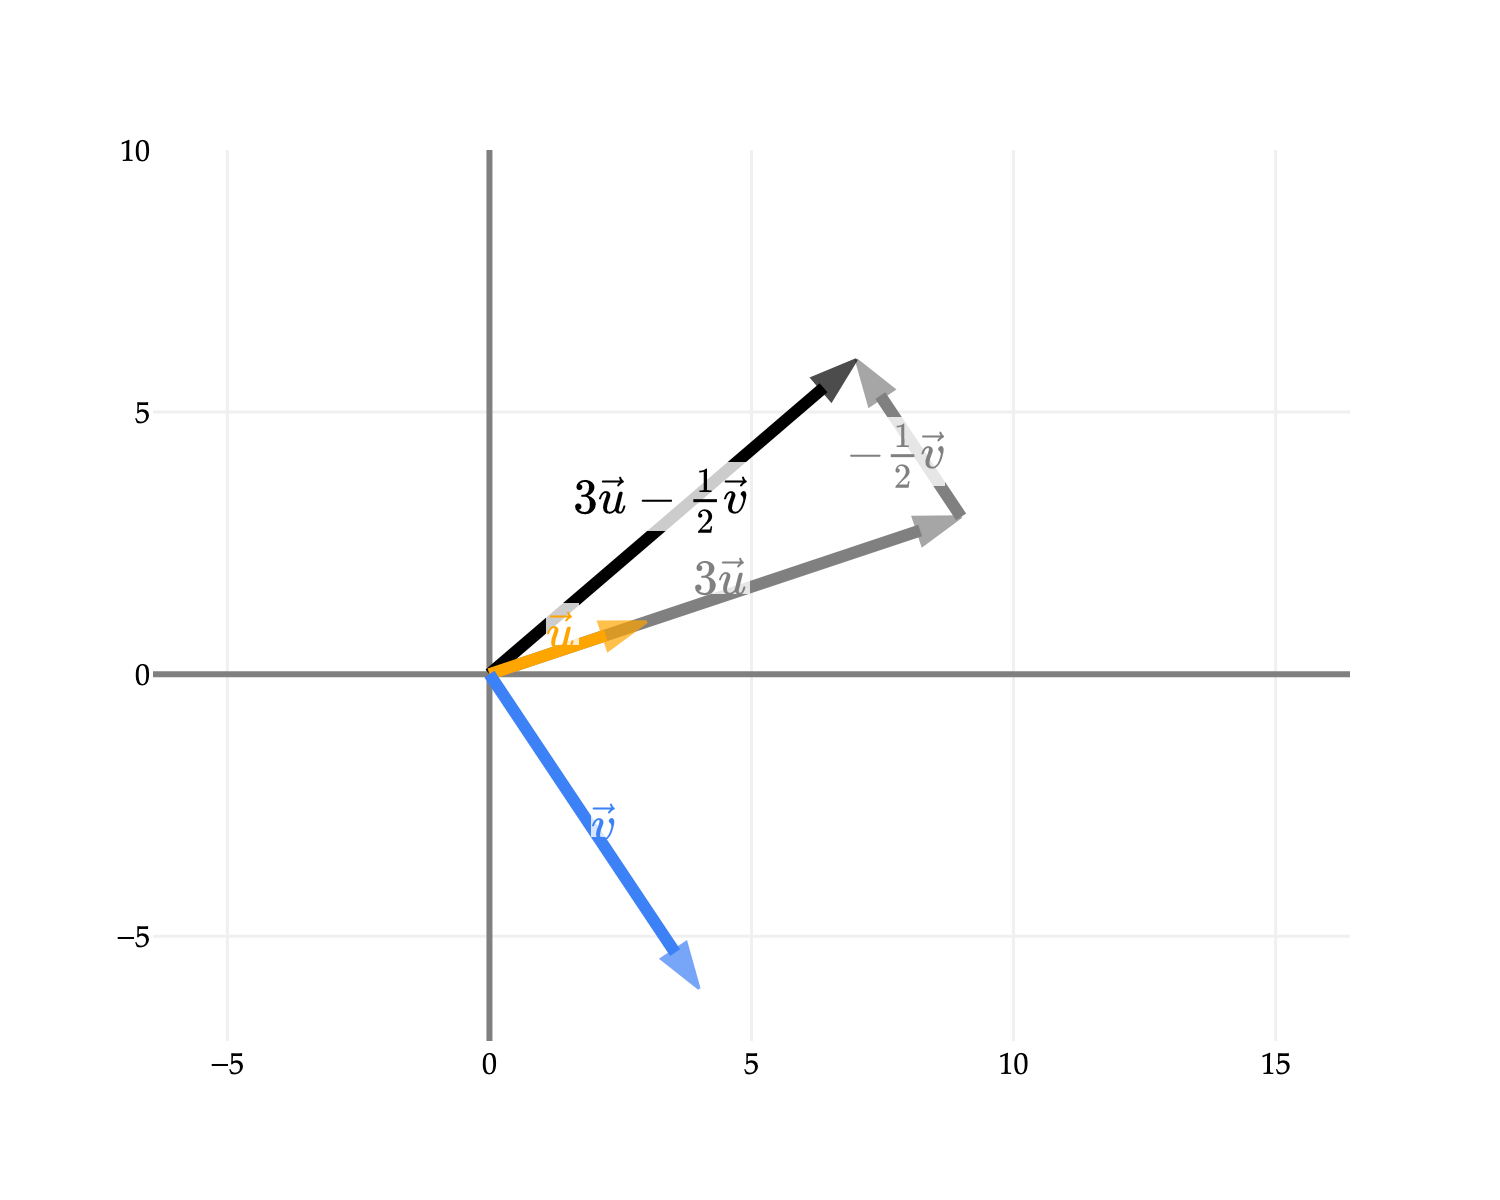

In [24]:
from utils import plot_vectors_non_origin
import numpy as np

# Define coefficients (easily changeable)
c1 = 3
c2 = -1/2

# Define original vectors
u = np.array([3, 1])
v = np.array([4, -6])

# Calculate scaled vectors
scaled_u = c1 * u  # -2u
scaled_v = c2 * v  # 1.5v
result = scaled_u + scaled_v  # -2u + 1.5v

# Calculate positions for vector addition visualization
origin = np.array([0, 0])
end_of_scaled_u = origin + scaled_u
end_of_result = origin + result

# Create vector list for plotting
vectors = [
    # Step 1: -2u starting at origin (gray)
    ((tuple(origin), tuple(end_of_scaled_u)), 'gray', f'${c1} \\vec u$'),
    
    # Step 2: 1.5v starting from end of -2u (gray)
    ((tuple(end_of_scaled_u), tuple(end_of_result)), 'gray', f'$-\\frac{1}{2} \\vec v$'),
    
    # Final result: -2u + 1.5v (black)
    ((tuple(origin), tuple(end_of_result)), 'black', f'$3 \\vec u -\\frac{1}{2} \\vec v$'),
    
    # Reference vectors (original u and v)
    ((tuple(origin), tuple(u)), 'orange', r'$\vec u$'),
    ((tuple(origin), tuple(v)), '#3d81f6', r'$\vec v$')
]

fig = plot_vectors_non_origin(vectors, vdeltax=0.3, vdeltay=0.5)
fig.update_layout(width=500, height=400, yaxis_scaleanchor="x",
                  xaxis_range=[-5, 15])
fig.show(scale=3)

:::{note} Definition: Linear Combination

Suppose ${\color{#d81b60} \vec v_1}, {\color{#d81b60} \vec v_2}, \ldots, {\color{#d81b60} \vec v_d}$ are all vectors in $\mathbb{R}^n$ and $a_1, a_2, \ldots, a_d$ are scalars (sometimes called coefficients). Then, a **linear combination** of the vectors ${\color{#d81b60} \vec v_1}, {\color{#d81b60} \vec v_2}, \ldots, {\color{#d81b60} \vec v_d}$ is any vector that can be written as:

$$a_1 {\color{#d81b60} \vec v_1} + a_2 {\color{#d81b60} \vec v_2} + \cdots + a_d {\color{#d81b60} \vec v_d}$$
:::

The vector $\begin{bmatrix} 7 \\ 6 \end{bmatrix}$, drawn in black above, is a linear combination of $\color{orange}\vec u$ and $\color{#3d81f6}\vec v$, since it can be written in the form $3{\color{orange}\vec u} - \frac{1}{2}{\color{#3d81f6}\vec v}$. $3$ and $-\frac{1}{2}$ are the scalars that the definition above refers to as $a_1$ and $a_2$, and we've used $\color{orange}\vec u$ and $\color{#3d81f6}\vec v$ in place of $\color{#d81b60}\vec v_1$ and $\color{#d81b60}\vec v_2$. (I've tried to make the definition a bit more general – here, we're just working with $d = 2$ vectors in $n = 2$ dimensions, but in practice $d$ and $n$ could both be much larger.)

### Example in 2D

Here's another linear combination of $\color{orange}\vec u$ and $\color{#3d81f6}\vec v$, namely $6{\color{orange}\vec u} + 5{\color{#3d81f6}\vec v}$. Algebraically, this is:

$$6{\color{orange}\vec u} + 5{\color{#3d81f6}\vec v} = 6{\color{orange}\begin{bmatrix} 3 \\ 1 \end{bmatrix}} + 5{\color{#3d81f6}\begin{bmatrix} 4 \\ -6 \end{bmatrix}} = \begin{bmatrix} 38 \\ -24 \end{bmatrix}$$

Visually:

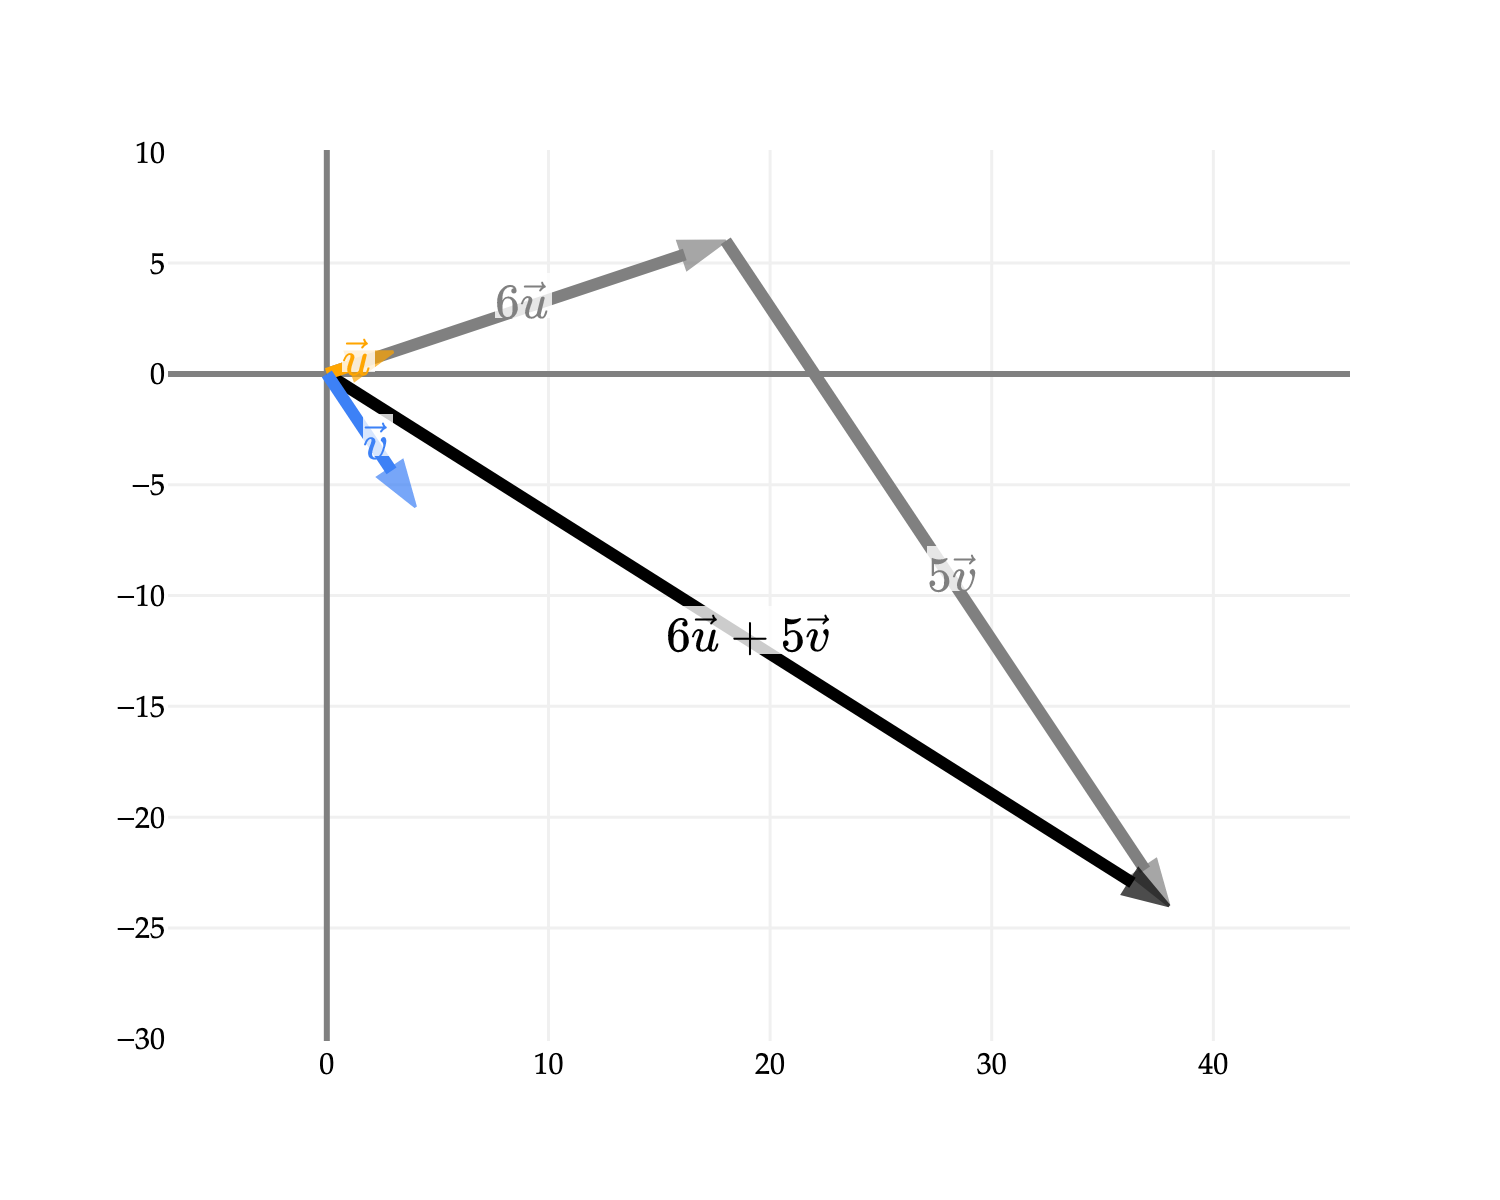

In [25]:
from utils import plot_vectors_non_origin
import numpy as np

# Define coefficients (easily changeable)
c1 = 6
c2 = 5

# Define original vectors
u = np.array([3, 1])
v = np.array([4, -6])

# Calculate scaled vectors
scaled_u = c1 * u  # -2u
scaled_v = c2 * v  # 1.5v
result = scaled_u + scaled_v  # -2u + 1.5v

# Calculate positions for vector addition visualization
origin = np.array([0, 0])
end_of_scaled_u = origin + scaled_u
end_of_result = origin + result

# Create vector list for plotting
vectors = [
    # Step 1: -2u starting at origin (gray)
    ((tuple(origin), tuple(end_of_scaled_u)), 'gray', f'${c1} \\vec u$'),
    
    # Step 2: 1.5v starting from end of -2u (gray)
    ((tuple(end_of_scaled_u), tuple(end_of_result)), 'gray', f'${c2} \\vec v$'),
    
    # Final result: -2u + 1.5v (black)
    ((tuple(origin), tuple(end_of_result)), 'black', f'${c1} \\vec u {"+" if c2 >= 0 else ""} {c2} \\vec v$'),
    
    # Reference vectors (original u and v)
    ((tuple(origin), tuple(u)), 'orange', r'$\vec u$'),
    ((tuple(origin), tuple(v)), '#3d81f6', r'$\vec v$')
]

fig = plot_vectors_non_origin(vectors, vdeltax=0.3, vdeltay=0.5)
fig.update_layout(width=500, height=400, yaxis_scaleanchor="x")
fig.update_layout(xaxis_range=[-1, 40], yaxis_range=[-30, 10])
fig.show(scale=3)

I like thinking of a linear combination as taking "a little bit of the first vector, a little bit of the second vector, etc." and then adding them all together. (By "little bit", I mean some amount of, e.g. $6 {\color{orange}\vec u}$ is a little bit of $\color{orange}\vec u$.) Another useful analogy is to think of the original vectors as "building blocks" that we can use to create new vectors through addition and scalar multiplication.

This idea, of creating new vectors by scaling and adding existing vectors, is **so important** that it's essentially what our multiple linear regression problem boils down to. 

In the context of our commute times example, imagine $\vec{\text{dept}}$ contains the home departure time, in hours, for each row in our dataset, and $\vec{\text{dom}}$ contains the day of the month for each row in our dataset. If we want to use these two features in a linear model to predict commute time, our problem boils down to finding the optimal coefficients $w_0$, $w_1$, and $w_2$ in a linear combination of $\vec 1$, $\vec{\text{dept}}$ and $\vec{\text{dom}}$ that best predicts commute times.

$$\text{vector of predicted commute times} = w_0 \underbrace{\begin{bmatrix} 1 \\ 1 \\ \vdots \\ 1 \end{bmatrix}}_{\vec 1} + w_1 \vec{\text{dept}} + w_2 \vec{\text{dom}}$$

Think about why $\vec 1$ is necessary.

### The Three Questions

We're going to spend a **lot** of time thinking about linear combinations. Specifically:

:::{attention} The Three Questions with Linear Combinations

Given a set of vectors $\vec v_1, \vec v_2, \ldots, \vec v_d$ and a vector $\vec b$, all in $\mathbb{R}^n$:

1. **Can we** write $\vec b$ as a linear combination of $\vec v_1, \vec v_2, \ldots, \vec v_d$?
1. If so, are the values of the scalars $a_1, a_2, \ldots, a_d$ **unique**?
1. What is the **shape** of the set of all possible linear combinations of $\vec v_1, \vec v_2, \ldots, \vec v_d$?

:::

Again, just as an example, suppose the two vectors we're dealing with are our familiar friends:

$${\color{orange}\vec u = \begin{bmatrix} 3 \\ 1 \end{bmatrix}}, \quad {\color{#3d81f6}\vec v = \begin{bmatrix} 4 \\ -6 \end{bmatrix}}$$

These are $d = 2$ vectors in $n = 2$ dimensions. With regards to the Three Questions:

1. **Can we** write $\vec b$ as a linear combination of ${\color{orange}\vec u}$ and ${\color{#3d81f6}\vec v}$?

    If $\vec b = \begin{bmatrix} 7 \\ 6 \end{bmatrix}$, then the answer to the first question is yes, because we've shown that: $$3 {\color{orange}\vec u} - \frac{1}{2} {\color{#3d81f6}\vec v} = \begin{bmatrix} 7 \\ 6 \end{bmatrix}$$ 
    
    Similarly, if $\vec b = \begin{bmatrix} 38 \\ -24 \end{bmatrix}$, then the answer to the first question is also yes, because we've shown that: $$6 {\color{orange}\vec u} + 5 {\color{#3d81f6}\vec v} = \begin{bmatrix} 38 \\ -24 \end{bmatrix}$$

    If $\vec b$ is some other vector, the answer may be yes or no, for all we know right now.

2. If so, are the values of the scalars on ${\color{orange}\vec u}$ and ${\color{#3d81f6}\vec v}$ **unique**?

    Not sure! It's true that $\begin{bmatrix} 7 \\ 6 \end{bmatrix} = 3 {\color{orange}\vec u} - \frac{1}{2} {\color{#3d81f6}\vec v}$, but for all I know at this point, there _could be_ other scalars $a_1 \neq 3$ and $a_2 \neq -\frac{1}{2}$ such that: $$a_1 {\color{orange}\vec u} + a_2 {\color{#3d81f6}\vec v} = \begin{bmatrix} 7 \\ 6 \end{bmatrix}$$
    
    (As it turns out, the answer is that the values $3$ and $-\frac{1}{2}$ **are** unique – you'll show why this is the case in a following activity.)

3. What is the **shape** of the set of all possible linear combinations of ${\color{orange}\vec u}$ and ${\color{#3d81f6}\vec v}$?

    Also not sure! I know that $\begin{bmatrix} 7 \\ 6 \end{bmatrix}$ and $\begin{bmatrix} 38 \\ -24 \end{bmatrix}$ are both linear combinations of $\color{orange}\vec u$ and $\color{#3d81f6}\vec v$, and presumably there are many more, but I don't know what they are. 
    
    (It turns out that **any** vector in $\mathbb{R}^2$ can be written as a linear combination of $\color{orange}\vec u$ and $\color{#3d81f6}\vec v$! Again, you'll show this in an activity.)

We'll more comprehensively study the "Three Questions" starting in [Chapter 4.1](../04_linear_independence/01-span.ipynb). I just wanted to call them out for you here so that you know where we're heading.

### Example in 3D

Let's move to 3D. Consider the vectors:

$${\color{#d81b60}\vec w = \begin{bmatrix} 12 \\ -4 \\ 6 \end{bmatrix}}, \quad {\color{#004d40}\vec r = \begin{bmatrix} 7 \\ 1 \\ 10 \end{bmatrix}}$$

These are $d = 2$ vectors, as before, but now in $n = 3$ dimensions. What do some of their linear combinations look like?

In [1]:
from pathlib import Path
import sys
_notes_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'myst.yml').exists())
if str(_notes_root) not in sys.path:
    sys.path.insert(0, str(_notes_root))
from plane_style import (BLUE, ORANGE, PINK, GRAY, plane_figure, add_plane,
                         vector3, vector_label, line3, label3,
                         style_surface_planes, projection_figure)
import numpy as np
import plotly.graph_objects as go

w = np.array([12,-4,6])
r = np.array([7,1,10])
fig = plane_figure(bounds=(-42,42), camera=dict(x=-2,y=1,z=0.8))
add_plane(fig, np.cross(w,r), name='Toggle plane')
vector3(fig,w,vector_label('w'),PINK,offset=(2,-3,1))
vector3(fig,r,vector_label('r'),'#004d40',offset=(-4,2,2))
for end in [w+2*r,2*w+r]:
    vector3(fig,end,'',GRAY)
vector3(fig,-0.75*w-3*r,'−0.75'+vector_label('w')+' − 3'+vector_label('r'),GRAY,offset=(2,0,-3))
fig.update_layout(showlegend=True, legend=dict(x=0,y=1))
fig.show(renderer='plotly_mimetype')


Rotate the plot above. You'll see that all linear combinations of ${\color{#d81b60}\vec w}$ and ${\color{#004d40}\vec r}$ lie on the same <span style="color: #3d81f6; font-weight: bold">plane</span>! Think of this plane as a flat sheet of paper that is tilted to align with ${\color{#d81b60}\vec w}$ and ${\color{#004d40}\vec r}$, that extends infinitely in all directions. Soon, we will learn to call this plane the **span** of ${\color{#d81b60}\vec w}$ and ${\color{#004d40}\vec r}$.

Is it the case that any two vectors in $\mathbb{R}^3$ together span a plane? Not necessarily: if the two vectors point in the same direction, then they both lie on the same line, and so the set of all linear combination of the two vectors is just a line, not a plane. The vectors $\begin{bmatrix} 1 \\ 2 \\ 3 \end{bmatrix}$ and $\begin{bmatrix} 2 \\ 4 \\ 6 \end{bmatrix}$ are a good example of this: any vector you can reach with a linear combination of these two vectors is a scalar multiple of $\begin{bmatrix} 1 \\ 2 \\ 3 \end{bmatrix}$, since $\begin{bmatrix} 2 \\ 4 \\ 6 \end{bmatrix} = 2 \begin{bmatrix} 1 \\ 2 \\ 3 \end{bmatrix}$. More on this in Chapter 4.

### The Systems of Equations Perspective

To illuminate the connection between linear combinations and systems of linear equations, I'd like to introduce another example. Let $\vec x = \begin{bmatrix} 3 \\ -1 \\ 2 \end{bmatrix}$ and $\vec y = \begin{bmatrix} 1 \\ 4 \\ 3 \end{bmatrix}$. $\vec x$ and $\vec y$ are both vectors in $\mathbb{R}^3$ and don't point in the same direction (i.e. $\vec y$ is not a scalar multiple of $\vec x$, and vice versa), so they span a plane.

Suppose we'd like to write $\vec b = \begin{bmatrix} 9 \\ -16 \\ -1 \end{bmatrix}$ as a linear combination of $\vec x$ and $\vec y$. In other words, we want to find scalars $c$ and $d$ such that:

$$c \vec x + d \vec y = \begin{bmatrix} 9 \\ -16 \\ -1 \end{bmatrix}$$

To do so, we can write the vector equation above as:

$$\begin{bmatrix} 3c \\ -c \\ 2c \end{bmatrix} + \begin{bmatrix} d \\ 4d \\ 3d \end{bmatrix} = \begin{bmatrix} 9 \\ -16 \\ -1 \end{bmatrix}$$

or

$$\begin{bmatrix} 3c + d \\ -c + 4d \\ 2c + 3d \end{bmatrix} = \begin{bmatrix} 9 \\ -16 \\ -1 \end{bmatrix}$$

This gives us a system of three equations with two unknowns, $c$ and $d$. There may or may not be a solution to this system, but we can try to find one.

$$
\begin{aligned}
3c + d &= 9 \\
-c + 4d &= -16 \\
2c + 3d &= -1
\end{aligned}
$$


We can solve this system using any method we'd like. Here, I'll use substitution.

First, solve the first equation for $d$:

$$d = 9 - 3c$$

Next, substitute this expression for $d$ into the second equation:

$$\begin{aligned}
-c + 4(9 - 3c) &= -16 \\
-c + 36 - 12c &= -16 \\
-13c + 36 &= -16 \\
-13c &= -52 \\
c &= 4
\end{aligned}
$$

Now, substitute $c = 4$ back into the expression for $d$:

$$d = 9 - 3(4) = 9 - 12 = -3$$

Is the solution $\boxed{(c, d) = (4, -3)}$ consistent? We can verify by substituting $c = 4$ and $d = -3$ back into the original equation:

$$4 \begin{bmatrix} 3 \\ -1 \\ 2 \end{bmatrix} - 3 \begin{bmatrix} 1 \\ 4 \\ 3 \end{bmatrix} = \begin{bmatrix} 9 \\ -16 \\ -1 \end{bmatrix}$$

So, indeed, $c = 4$ and $d = -3$ are the coefficients that allow us to write $\begin{bmatrix} 9 \\ -16 \\ -1 \end{bmatrix}$ as a linear combination of $\begin{bmatrix} 3 \\ -1 \\ 2 \end{bmatrix}$ and $\begin{bmatrix} 1 \\ 4 \\ 3 \end{bmatrix}$. This tells us how much to take of $\begin{bmatrix} 3 \\ -1 \\ 2 \end{bmatrix}$ and $\begin{bmatrix} 1 \\ 4 \\ 3 \end{bmatrix}$ to make $\begin{bmatrix} 9 \\ -16 \\ -1 \end{bmatrix}$.

To find these coefficients, we solved a system of three equations with two unknowns.

$$
\begin{aligned}
3c + d &= 9 \\
-c + 4d &= -16 \\
2c + 3d &= -1
\end{aligned}
$$

Each of the three equations above is a line in the $cd$-plane. The first one, $3c + d = 9$, can be rewritten as $d = -3c + 9$, which is a line with slope $-3$ and $y$-intercept $9$, for instance.

What does this system **look like** in the $cd$-plane?

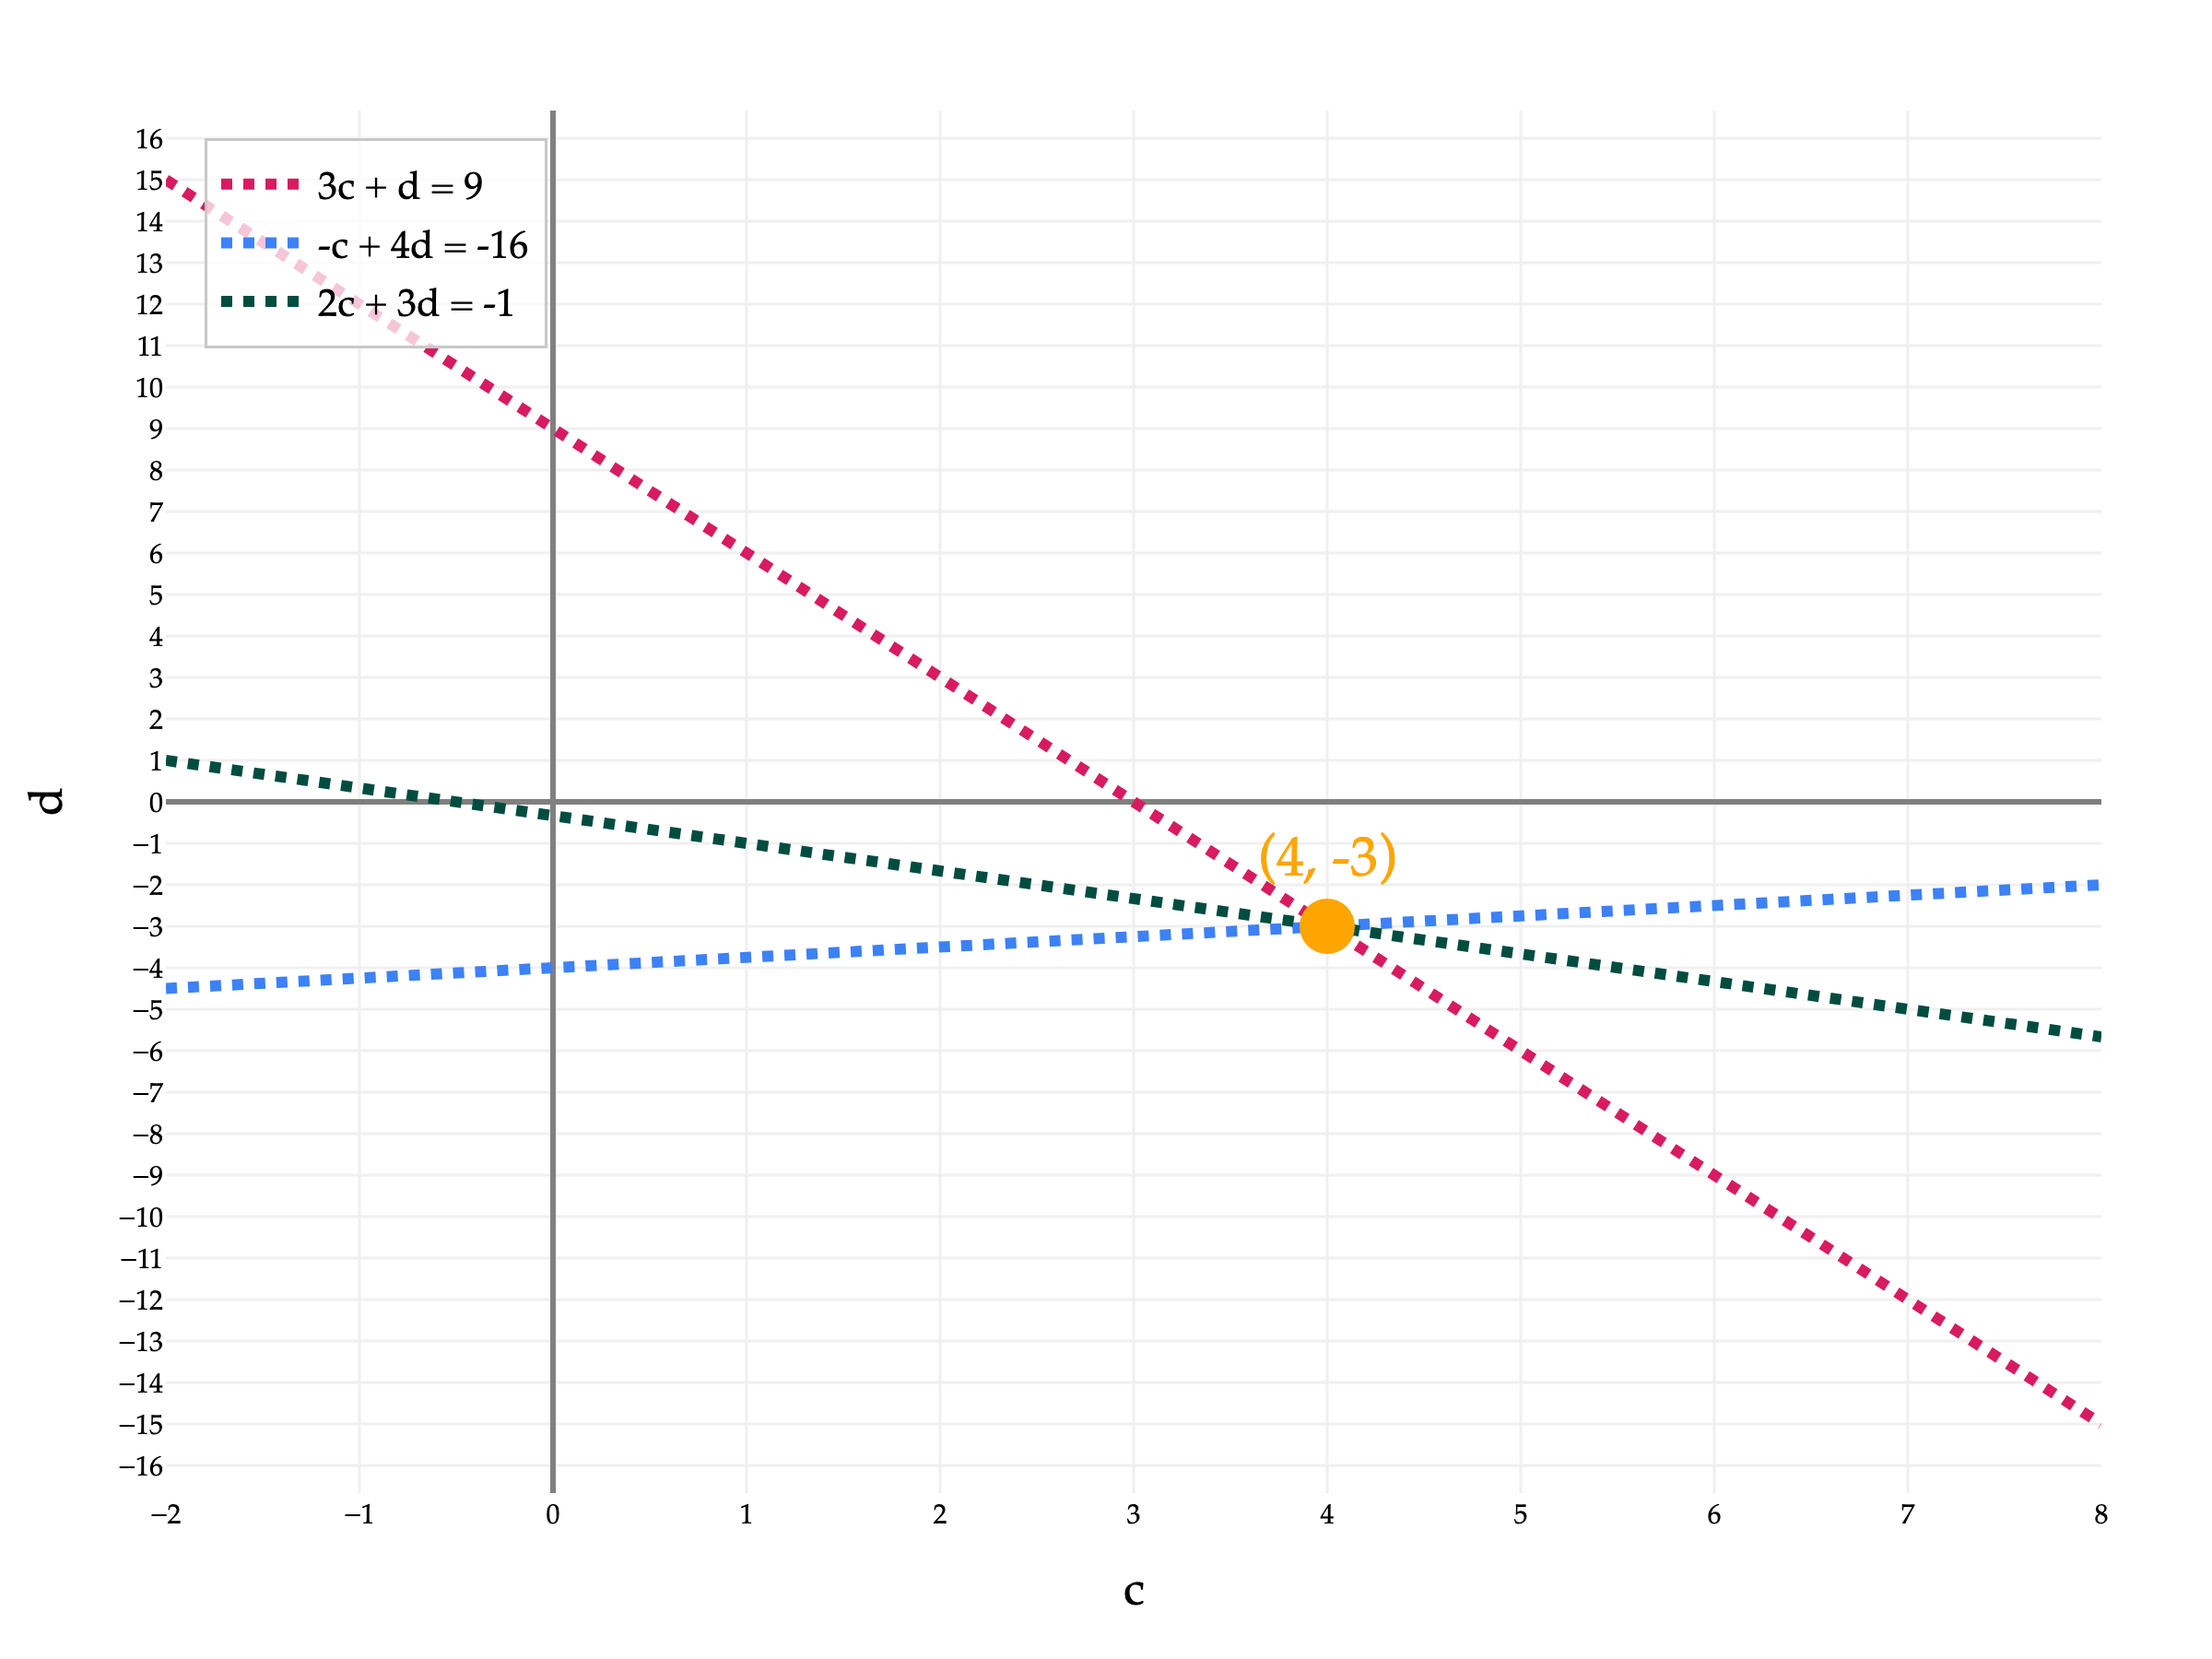

In [20]:
import numpy as np
import plotly.graph_objects as go

# Lines in the (c, d) plane
# 3c + d = 9
# -c + 4d = -16
# 2c + 3d = -1

c = np.linspace(-2, 8, 10)
d1 = 9 - 3*c
d2 = (c - 16) / 4
d3 = (-1 - 2*c) / 3

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=c, y=d1,
    mode='lines',
    name='3c + d = 9',
    line=dict(color='#d81b60', width=4, dash='dot'),
    hovertemplate='c=%{x:.2f}<br>d=%{y:.2f}<extra></extra>',
))

fig.add_trace(go.Scatter(
    x=c, y=d2,
    mode='lines',
    name='-c + 4d = -16',
    line=dict(color='#3d81f6', width=4, dash='dot'),
    hovertemplate='c=%{x:.2f}<br>d=%{y:.2f}<extra></extra>',
))

fig.add_trace(go.Scatter(
    x=c, y=d3,
    mode='lines',
    name='2c + 3d = -1',
    line=dict(color='#004d40', width=4, dash='dot'),
    hovertemplate='c=%{x:.2f}<br>d=%{y:.2f}<extra></extra>',
))

fig.update_layout(
    width=800,
    height=600,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family='Palatino', size=14, color='black'),
    margin=dict(l=60, r=40, t=40, b=60),
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor='rgba(255,255,255,0.75)',
        bordercolor='rgb(200,200,200)',
        borderwidth=1,
    ),
)

fig.update_xaxes(
    title_text='c',
    gridcolor='#f0f0f0',
    zerolinecolor='gray',
    tickfont=dict(size=10),
    tickmode='linear',
    tick0=0,
    dtick=1,
)

fig.update_yaxes(
    title_text='d',
    gridcolor='#f0f0f0',
    zerolinecolor='gray',
    tickfont=dict(size=10),
    tickmode='linear',
    tick0=0,
    dtick=1,
)

fig.add_trace(go.Scatter(
    x=[4],
    y=[-3],
    mode='markers+text',
    marker=dict(color='orange', size=20),
    text=["(4, -3)"],
    textposition="top center",
    textfont=dict(size=20, color='orange'),
    hovertemplate='c=%{x}<br>d=%{y}<extra></extra>',
    showlegend=False,
))

fig.show(config={'displayModeBar': False}, renderer='png', scale=3)


The three lines in this system intersect at the point $(4, -3)$, which is the solution to the system of equations. Because all three lines intersect at a single point, there is a unique solution, meaning there is **only one way** to write $\vec b = \begin{bmatrix} 9 \\ -16 \\ -1 \end{bmatrix}$ as a linear combination of $\vec x = \begin{bmatrix} 3 \\ -1 \\ 2 \end{bmatrix}$ and $\vec y = \begin{bmatrix} 1 \\ 4 \\ 3 \end{bmatrix}$.

### Another Example

To illustrate what could go wrong, let's look at one final example. We'll keep the same $\vec x = \begin{bmatrix} 3 \\ -1 \\ 2 \end{bmatrix}$ and $\vec y = \begin{bmatrix} 1 \\ 4 \\ 3 \end{bmatrix}$, but choose a different "right-hand side" vector to create, say

$$\vec b = \begin{bmatrix} 9 \\ -16 \\ 2 \end{bmatrix}$$

Then the constraint equations are

$$
\begin{aligned}
3c + d &= 9 \\
-c + 4d &= -16 \\
2c + 3d &= 2
\end{aligned}$$

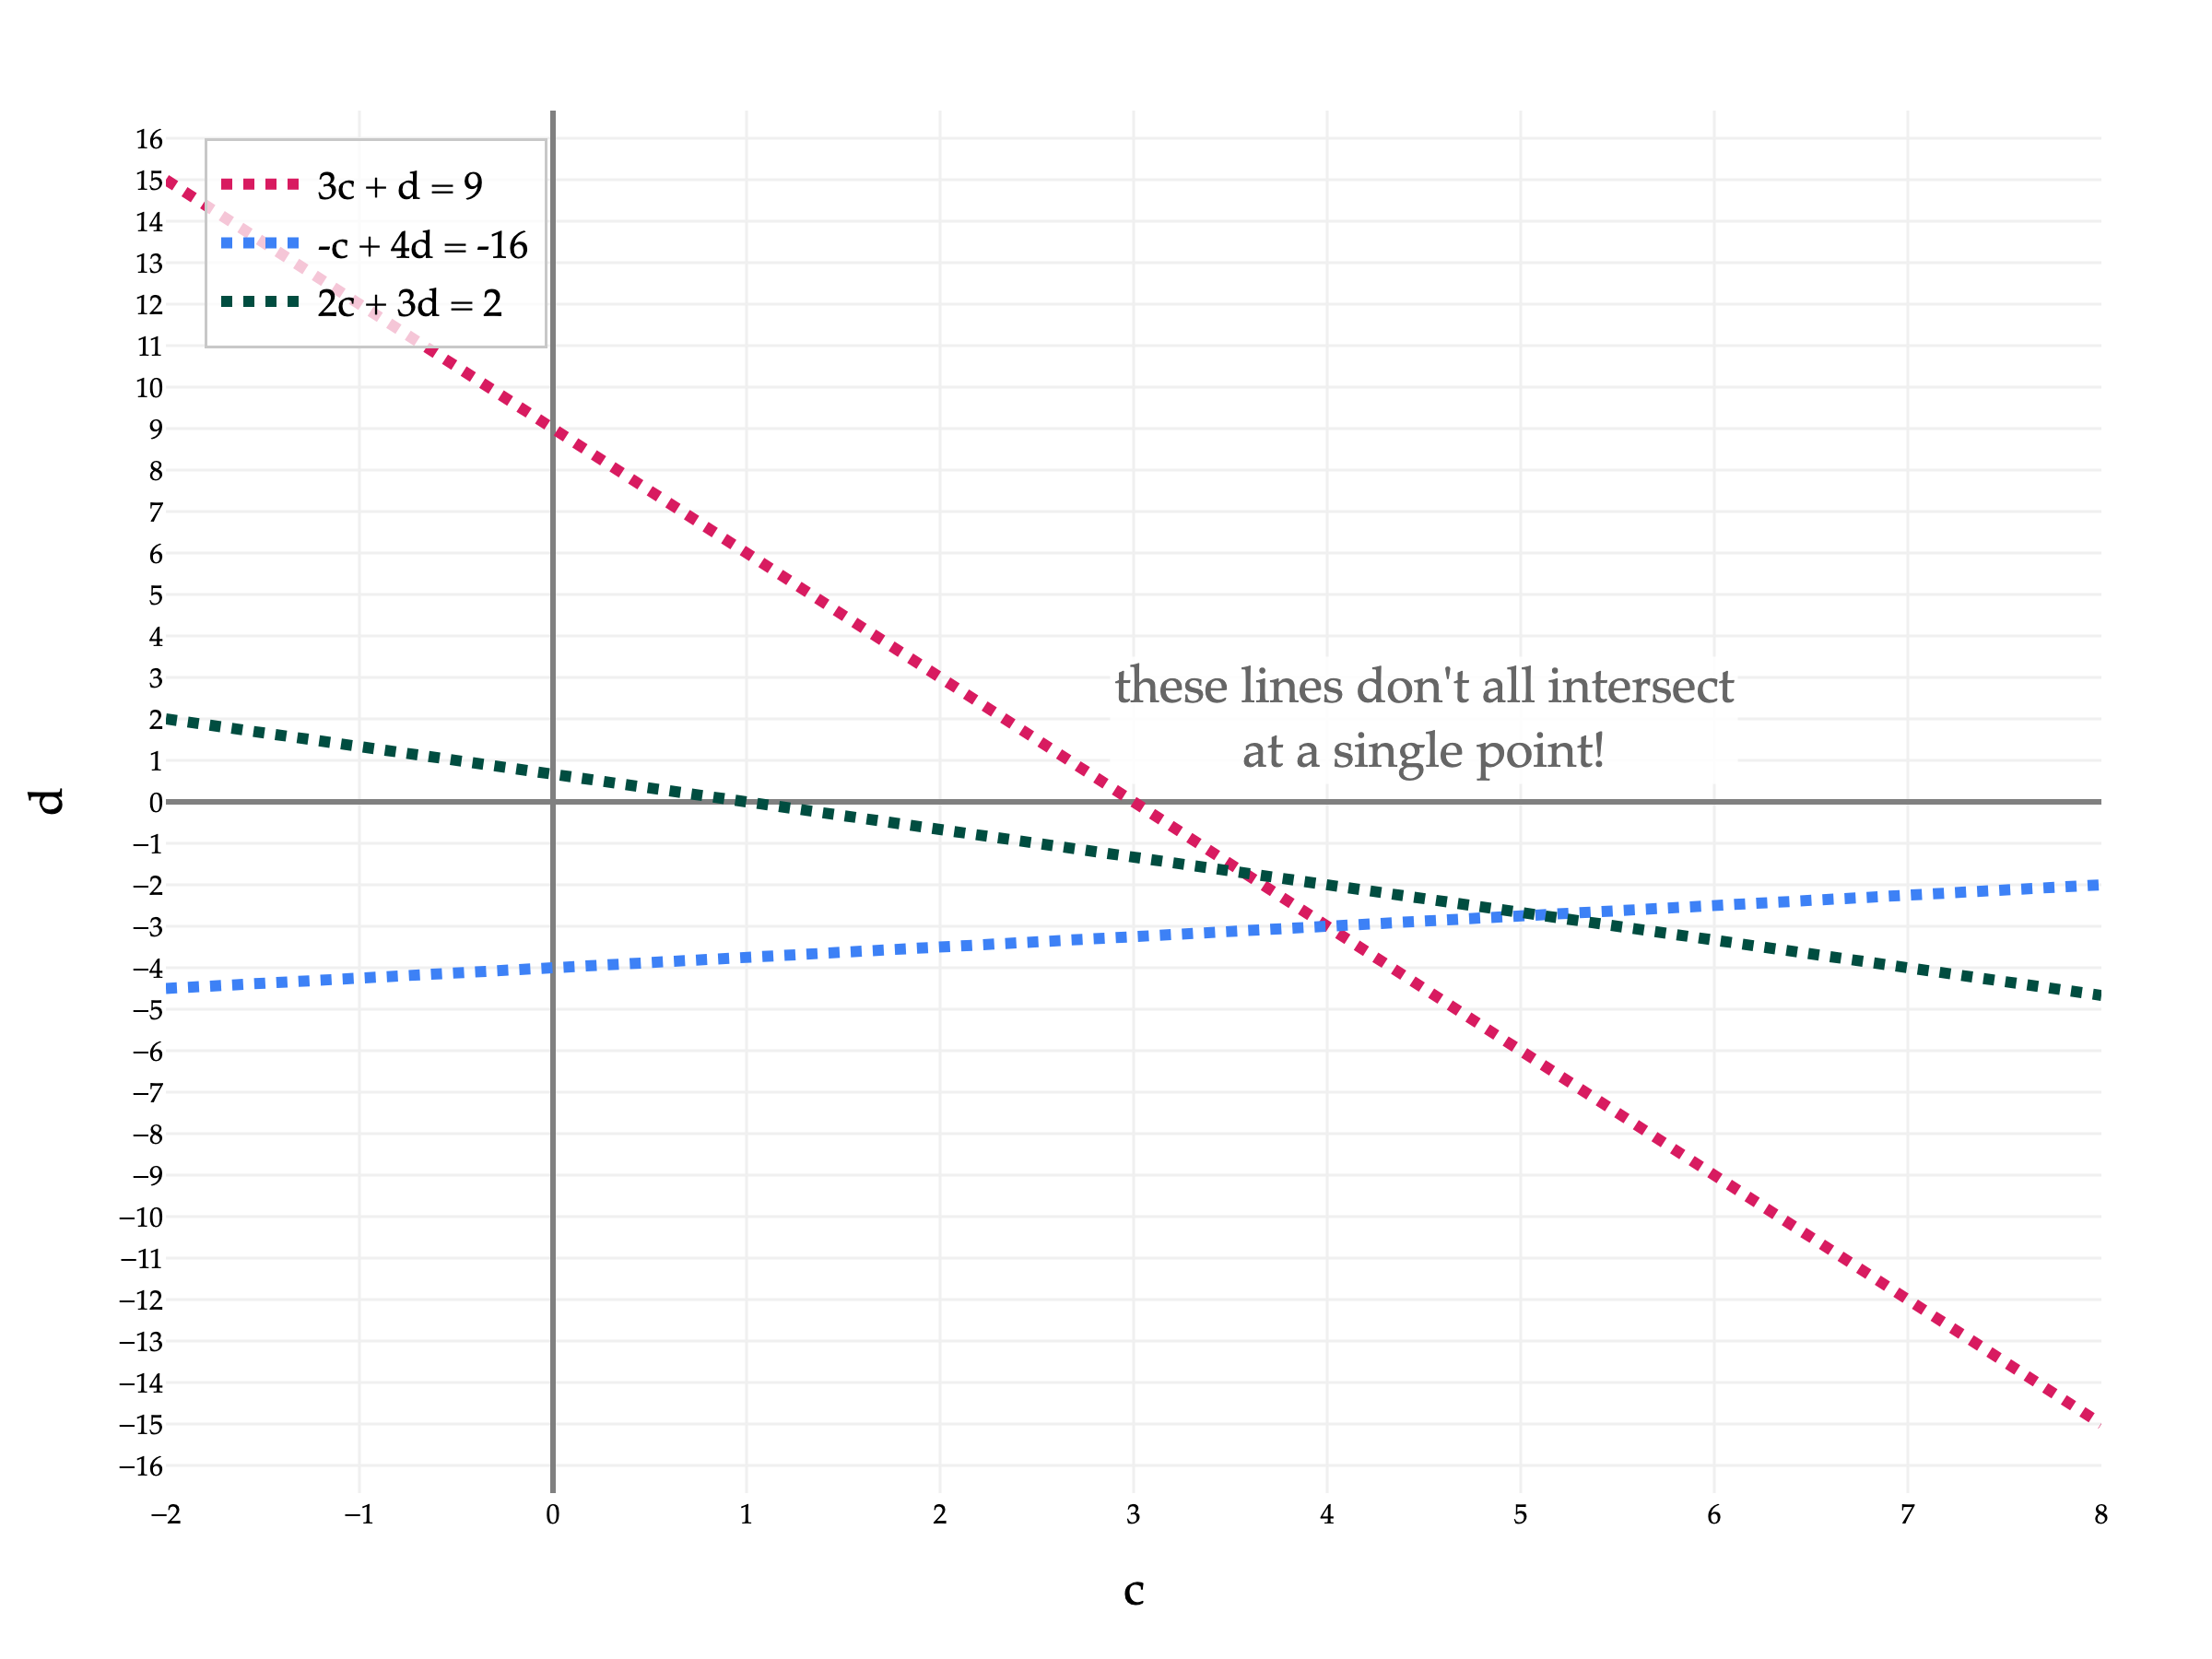

In [8]:
import numpy as np
import plotly.graph_objects as go

# Lines in the (c, d) plane for the NEW vector b = [9, -16, 2]
# 3c + d = 9
# -c + 4d = -16
# 2c + 3d = 2

c = np.linspace(-2, 8, 200)
d1 = 9 - 3*c              # From 3c + d = 9
d2 = (c - 16) / 4         # From -c + 4d = -16
d3 = (2 - 2*c) / 3        # From 2c + 3d = 2

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=c, y=d1,
    mode='lines',
    name='3c + d = 9',
    line=dict(color='#d81b60', width=4, dash='dot'),
    hovertemplate='c=%{x:.2f}<br>d=%{y:.2f}<extra></extra>',
))

fig.add_trace(go.Scatter(
    x=c, y=d2,
    mode='lines',
    name='-c + 4d = -16',
    line=dict(color='#3d81f6', width=4, dash='dot'),
    hovertemplate='c=%{x:.2f}<br>d=%{y:.2f}<extra></extra>',
))

fig.add_trace(go.Scatter(
    x=c, y=d3,
    mode='lines',
    name='2c + 3d = 2',
    line=dict(color='#004d40', width=4, dash='dot'),
    hovertemplate='c=%{x:.2f}<br>d=%{y:.2f}<extra></extra>',
))

fig.update_layout(
    width=800,
    height=600,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family='Palatino', size=14, color='black'),
    margin=dict(l=60, r=40, t=40, b=60),
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor='rgba(255,255,255,0.75)',
        bordercolor='rgb(200,200,200)',
        borderwidth=1,
    ),
)

fig.update_xaxes(
    title_text='c',
    gridcolor='#f0f0f0',
    zerolinecolor='gray',
    tickfont=dict(size=10),
    tickmode='linear',
    tick0=0,
    dtick=1,
)

fig.update_yaxes(
    title_text='d',
    gridcolor='#f0f0f0',
    zerolinecolor='gray',
    tickfont=dict(size=10),
    tickmode='linear',
    tick0=0,
    dtick=1,
)

# Annotate the plot to clearly state "these lines don't intersect!" near the middle
fig.add_annotation(
    x=4.5,  # A c-value near the horizontal midpoint of the visible range
    y=2,    # A typical d-value near the vertical mid
    text="these lines don't all intersect<br>at a single point!",
    showarrow=False,
    font=dict(size=18, color="#666", family="Palatino"),
    align="center",
    bgcolor="rgba(255,255,255,0.9)",
    # bordercolor="crimson",
    # borderwidth=2,
    opacity=1.0,
)

# NOTE: For the system with b = [9, -16, 2], the lines do not intersect at a common point.
# The intersection point (4, -3) from the previous example is not a solution here, so do not highlight it.
# However, if you wish, you could compute/annotate pairwise intersections in a different part of the notebook.

fig.show(config={'displayModeBar': False}, renderer='png', scale=3)


Each pair of lines still intersects in the $cd$-plane, but all three points of intersection are different. As such, there are no scalars $c$ and $d$ such that

$$c \begin{bmatrix} 3 \\ -1 \\ 2 \end{bmatrix} + d \begin{bmatrix} 1 \\ 4 \\ 3 \end{bmatrix} = \begin{bmatrix} 9 \\ -16 \\ 2 \end{bmatrix}$$

meaning that $\begin{bmatrix} 9 \\ -16 \\ 2 \end{bmatrix}$ **cannot** be written as a linear combination of $\begin{bmatrix} 3 \\ -1 \\ 2 \end{bmatrix}$ and $\begin{bmatrix} 1 \\ 4 \\ 3 \end{bmatrix}$.

So far, we've seen two cases:
- $\vec b$ could be written **exactly one way** as a linear combination of $\vec x$ and $\vec y$
- $\vec b$ **could not** be written as a linear combination of $\vec x$ and $\vec y$

In [Chapter 4](../04_linear_independence/01-span.ipynb), we'll see that there's a third case: $\vec b$ could be written in **infinitely many ways** as a linear combination of $\vec x$ and $\vec y$.